## Condition Configuration

- `CONDITION`: condition name whose `all_proposals.json` and review outputs should be linked here.
- This notebook expects step 2 and step 3 outputs to already exist.


In [85]:
CONDITION = 'minimal'


# Review Score Prediction and Outlier Validation

## Overview

This notebook links the embedding and style metrics computed from proposal analyses to the latest AI-generated NCEMS and novelty review files for the selected condition.

**Two primary goals:**
1. **Metric validation** — test whether computed metrics (semantic diversity metrics such as controid_dist, is_outlier, is_most_novel etc) correlate and predict review scores (either ncems_criteria or novelty).

2. **Outlier validation** — test whether proposals identified as most semantically unique (top-10% nearest-neighbor distance within all proposals or within literature embedding space) actually received higher scores on "Novelty & Significance" from NCEMS criteria or each novelty score criteria from novelty reviews.

**Review data structure:**
- 92 proposals × 3 AI evaluators (GPT, Gemini, Claude) x 2 types of reviews (ncems criteria or novelty) = 276 reviews 
- From NCEMS criteria: 7 scored criteria: Relevance to Emergent Phenomena, Novelty & Significance, Rigor of Approach, Scope & Timeline, Synthesis Focus, Data Identification, Open Science Commitment
- From NOVELTY criteria: new_question_topic_or_framing, new_theory_concept_method_dataset_or_design, unusual_combination_of_existing_ideas, beyond_state_of_the_art, credible_high_risk_high_gain, unique_knowledge_generation


In [86]:
import sys
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP and embeddings
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.spatial.distance import cdist
from tqdm import tqdm

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu
import itertools

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate.resolve()
    raise RuntimeError('Could not find project root containing src/ and data/.')


PROJECT_ROOT = find_project_root()

print('✓ Imports successful')
print(f'✓ Working directory: {os.getcwd()}')
print(f'✓ Project root: {PROJECT_ROOT}')
print(f'✓ PyTorch version: {torch.__version__}')
print(f'✓ CUDA available: {torch.cuda.is_available()}')

try:
    import umap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap

condition = 'rephrased/minimal'
PREPARED_DIR = PROJECT_ROOT / 'data' / 'prepared' / condition
ALL_PROPOSALS_PATH = PREPARED_DIR / 'all_proposals.json'
ALL_PROPOSALS_ANALYSIS_PATH = PROJECT_ROOT / 'results' / 'tables' / 'rephrased' / 'minimal' / 'all_proposals.json'
NCEMS_ALL_REVIEWS_PATH = PREPARED_DIR / 'ncems_criteria_all_reviews.csv'
NOVELTY_ALL_REVIEWS_PATH = PREPARED_DIR / 'novelty_all_reviews.csv'
REVIEW_SCORES_WIDE_PATH = PREPARED_DIR / 'review_scores_wide.csv'
HUMAN_Y2_SCORES_WIDE_PATH = PREPARED_DIR / 'human_y2_scores_wide.csv'

PROPOSAL_METRICS_MASTER_PATH = PROJECT_ROOT / 'results' / 'tables' / 'rephrased' / 'minimal' / 'proposal_metrics_master.csv'
if not NCEMS_ALL_REVIEWS_PATH.exists() or not NOVELTY_ALL_REVIEWS_PATH.exists():
    raise FileNotFoundError('Prepared review tables are missing. Run prepare_data_for_analysis.ipynb first.')

RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures' / condition / 'metric-score'
TABLES_DIR = RESULTS_DIR / 'tables' / condition / 'metric-score'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


✓ Imports successful
✓ Working directory: /Users/eveyhuang/Documents/NICO/human-AI-proposal/baseline(minimal)-rephrased
✓ Project root: /Users/eveyhuang/Documents/NICO/human-AI-proposal
✓ PyTorch version: 2.9.1
✓ CUDA available: False


In [87]:
# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-5': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#3CB371',  # Dark orange
}

## 0. Load Prepared Review Score Tables (No Re-Aggregation)

In [88]:
# Load prepared score tables created by prepare_data_for_analysis.ipynb.

required_paths = [REVIEW_SCORES_WIDE_PATH, HUMAN_Y2_SCORES_WIDE_PATH]
for pth in required_paths:
    if not pth.exists():
        raise FileNotFoundError(
            f'Missing prepared artifact: {pth}. Run prepare_data_for_analysis.ipynb first.'
        )

proposals_path = ALL_PROPOSALS_PATH if ALL_PROPOSALS_PATH.exists() else ALL_PROPOSALS_ANALYSIS_PATH
if not proposals_path.exists():
    raise FileNotFoundError(
        f'Missing proposal artifact: {proposals_path}. Run prepare_data_for_analysis.ipynb (and compare_proposals_rephrased.ipynb if needed) first.'
    )

with open(proposals_path) as f:
    proposals = json.load(f)

review_scores_wide_df = pd.read_csv(REVIEW_SCORES_WIDE_PATH)
human_y2_scores_wide_df = pd.read_csv(HUMAN_Y2_SCORES_WIDE_PATH)

# Build normalized title keys for deterministic joins.
review_scores_wide_df['title_norm'] = review_scores_wide_df['title'].map(lambda x: str(x).strip().lower())
human_y2_scores_wide_df['title_norm'] = human_y2_scores_wide_df['title'].map(lambda x: str(x).strip().lower())

print(f'Loaded proposals: {len(proposals)} from {proposals_path}')
print(f'Loaded AI review score means: {REVIEW_SCORES_WIDE_PATH} ({len(review_scores_wide_df)} rows)')
print(f'Loaded Human-Y2 score means: {HUMAN_Y2_SCORES_WIDE_PATH} ({len(human_y2_scores_wide_df)} rows)')


Loaded proposals: 92 from /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/all_proposals.json
Loaded AI review score means: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/review_scores_wide.csv (92 rows)
Loaded Human-Y2 score means: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/human_y2_scores_wide.csv (11 rows)


In [89]:
# Validate prepared score-table columns

required_ai_cols = [
    'relevance_to_emergent_phenomena', 'novelty_and_significance', 'rigor_of_approach',
    'scope_and_timeline', 'synthesis_focus', 'data_identification',
    'open_science_commitment', 'review_score_mean',
    'new_question_topic_or_framing', 'new_theory_concept_method_dataset_or_design',
    'unusual_combination_of_existing_ideas', 'beyond_state_of_the_art',
    'credible_high_risk_high_gain', 'unique_knowledge_generation', 'novelty_score_mean',
]
missing_ai = [c for c in required_ai_cols if c not in review_scores_wide_df.columns]
if missing_ai:
    raise KeyError(f'review_scores_wide.csv missing expected columns: {missing_ai}')

required_hy2_cols = [
    'relevance_to_emergent_phenomena_human_y2',
    'novelty_and_significance_human_y2',
    'rigor_of_approach_human_y2',
    'scope_and_timeline_human_y2',
    'synthesis_focus_human_y2',
    'data_identification_human_y2',
    'open_science_commitment_human_y2',
    'review_score_mean_human_y2',
]
missing_hy2 = [c for c in required_hy2_cols if c not in human_y2_scores_wide_df.columns]
if missing_hy2:
    raise KeyError(f'human_y2_scores_wide.csv missing expected columns: {missing_hy2}')

print('Prepared score tables validated.')


Prepared score tables validated.


## 1. Load Data and Build Unified DataFrame

`all_proposals.json` now contains averaged NCEMS criteria scores and novelty scores from the three AI evaluators. Here we flatten it into a single pandas DataFrame.

In [90]:
# Use prepared proposal records as base input.
with open(ALL_PROPOSALS_PATH) as f:
    proposals = json.load(f)

print(f'Loaded {len(proposals)} proposals from {ALL_PROPOSALS_PATH}')
print(f"Groups: {set(p.get('group') for p in proposals)}")


Loaded 92 proposals from /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/all_proposals.json
Groups: {'gemini-3-pro-preview', 'claude-opus-4-5', 'gpt-5.2', 'Human'}


In [91]:
# Flatten proposals into a DataFrame, then merge prepared metrics + prepared score tables.
rows = []
for p in proposals:
    row = {
        'title':  p.get('title'),
        'group':  p.get('group'),
        'is_ai':  p.get('is_ai'),
        'model':  p.get('model'),
        'cohort': p.get('cohort'),
        'title_norm': p.get('title_norm'),
        'proposal_uid': p.get('proposal_uid'),
    }
    row.update(p.get('metrics', {}) or {})
    rows.append(row)

df = pd.DataFrame(rows)
df['_title_key'] = df['title'].astype(str).str.strip().str.lower()

# Merge prepared AI score means (NCEMS + novelty) from prepare_data_for_analysis outputs.
ai_scores = review_scores_wide_df.copy()
ai_scores['_title_key'] = ai_scores['title'].astype(str).str.strip().str.lower()
ai_score_cols = [c for c in ai_scores.columns if c not in {'title', 'title_norm', '_title_key'}]
df = df.merge(ai_scores[['_title_key', *ai_score_cols]], on='_title_key', how='left', suffixes=('', '_aiwide'))
for c in ai_score_cols:
    c2 = f'{c}_aiwide'
    if c2 in df.columns:
        if c in df.columns:
            df[c] = df[c].combine_first(df[c2])
            df.drop(columns=[c2], inplace=True)
        else:
            df.rename(columns={c2: c}, inplace=True)

# Merge prepared Human-Y2 score means from prepare_data_for_analysis outputs.
hy2 = human_y2_scores_wide_df.copy()
hy2['_title_key'] = hy2['title'].astype(str).str.strip().str.lower()
hy2_cols = [c for c in hy2.columns if c not in {'title', 'title_norm', '_title_key'}]
df = df.merge(hy2[['_title_key', *hy2_cols]], on='_title_key', how='left', suffixes=('', '_hy2wide'))
for c in hy2_cols:
    c2 = f'{c}_hy2wide'
    if c2 in df.columns:
        if c in df.columns:
            df[c] = df[c].combine_first(df[c2])
            df.drop(columns=[c2], inplace=True)
        else:
            df.rename(columns={c2: c}, inplace=True)

# Prefer unified proposal metric export from compare_proposals_rephrased.ipynb when present.
if PROPOSAL_METRICS_MASTER_PATH.exists():
    pm = pd.read_csv(PROPOSAL_METRICS_MASTER_PATH)
    pm['_title_key'] = pm['title'].astype(str).str.strip().str.lower()

    pm_meta_cols = {'proposal_uid', 'title', 'group_model', 'group_binary', 'is_ai', '_title_key'}
    pm_metric_cols = [c for c in pm.columns if c not in pm_meta_cols]

    if 'proposal_uid' in df.columns and df['proposal_uid'].notna().any() and 'proposal_uid' in pm.columns:
        pm_sub = pm[['proposal_uid', *pm_metric_cols]].drop_duplicates(subset=['proposal_uid'])
        df = df.merge(pm_sub, on='proposal_uid', how='left', suffixes=('', '_master'))
    else:
        pm_sub = pm[['_title_key', *pm_metric_cols]].drop_duplicates(subset=['_title_key'])
        df = df.merge(pm_sub, on='_title_key', how='left', suffixes=('', '_master'))

    for c in pm_metric_cols:
        c_master = f'{c}_master'
        if c_master in df.columns:
            if c in df.columns:
                df[c] = df[c].combine_first(df[c_master])
                df = df.drop(columns=[c_master])
            else:
                df = df.rename(columns={c_master: c})

    print(f'Merged unified proposal metrics from: {PROPOSAL_METRICS_MASTER_PATH}')
else:
    print(f'Unified proposal metrics file not found (using metrics from all_proposals.json only): {PROPOSAL_METRICS_MASTER_PATH}')

if '_title_key' in df.columns:
    df = df.drop(columns=['_title_key'])

print(f'DataFrame shape: {df.shape}')
print(f'\nColumns ({len(df.columns)}):')
print(list(df.columns))


Merged unified proposal metrics from: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/proposal_metrics_master.csv
DataFrame shape: (92, 66)

Columns (66):
['title', 'group', 'is_ai', 'model', 'cohort', 'title_norm', 'proposal_uid', 'review_score_mean', 'relevance_to_emergent_phenomena', 'novelty_and_significance', 'rigor_of_approach', 'scope_and_timeline', 'synthesis_focus', 'data_identification', 'open_science_commitment', 'novelty_score_mean', 'new_question_topic_or_framing', 'new_theory_concept_method_dataset_or_design', 'unusual_combination_of_existing_ideas', 'beyond_state_of_the_art', 'credible_high_risk_high_gain', 'unique_knowledge_generation', 'review_score_mean_human_y2', 'relevance_to_emergent_phenomena_human_y2', 'novelty_and_significance_human_y2', 'rigor_of_approach_human_y2', 'scope_and_timeline_human_y2', 'synthesis_focus_human_y2', 'data_identification_human_y2', 'open_science_commitment_human_y2', 'mean_pairwise_dist', 'centroid_dist

In [92]:

# Define metric families and score groups

DIVERSITY_METRICS_NEW = [
    'mean_pairwise_dist',
    'centroid_dist_raw',
    'centroid_dist_loo',
    'global_centroid_dist',
    'nn_dist_global',
    'mean_5nn_dist_global',
    'medoid_dist',
    'remote_clique_group',
    'chamfer_group',
    'mst_dispersion_group',
    'span90_group',
    'sparseness_group',
    'grid_entropy_group',
    'grid_entropy_group_norm',
]

NOVELTY_METRICS_NEW = [
    'element_novel_0',
    'element_novel_1',
    'element_novel_5',
    'element_novel_10',
    'mean_knn_5',
    'mean_knn_10',
    'mean_knn_20',
    'mean_knn_50',
    'novelty_ratio',
    'novelty_z',
]

# Keep legacy names for backward compatibility in case only older tables are available.
LEGACY_SEMANTIC_METRICS = [
    'centroid_dist', 'nn_dist', 'pairwise_mean_dist',
    'mi_centroid_dist', 'mi_nn_dist', 'mi_pairwise_mean_dist',
    'raw_novelty',
]

# Literature distance fallback (new and legacy names)
LIT_DIST_CANDIDATES = [
    'mean_knn_10',
    'mean_lit_nn_dist_k10',
    'mean_knn_5',
    'mean_lit_nn_dist_k5',
]
LIT_DIST_METRIC = next((c for c in LIT_DIST_CANDIDATES if c in df.columns), None)

# Build full semantic metric set from available columns.
semantic_candidates = []
semantic_candidates.extend(DIVERSITY_METRICS_NEW)
semantic_candidates.extend(NOVELTY_METRICS_NEW)
semantic_candidates.extend(LEGACY_SEMANTIC_METRICS)
if LIT_DIST_METRIC is not None:
    semantic_candidates.append(LIT_DIST_METRIC)

seen = set()
SEMANTIC_METRICS = []
for c in semantic_candidates:
    if c in df.columns and c not in seen:
        SEMANTIC_METRICS.append(c)
        seen.add(c)

STYLE_METRICS = [
    'n_words', 'n_chars', 'n_sents',
    'avg_word_len', 'avg_sent_len_words',
    'type_token_ratio', 'stopword_rate', 'hedge_rate',
    'flesch_reading_ease', 'fk_grade_level',
    'comma_per_1k_chars', 'semicolon_per_1k_chars',
    'newline_per_1k_chars', 'bullet_per_1k_chars',
]
STYLE_METRICS = [c for c in STYLE_METRICS if c in df.columns]

NCEMS_SCORES = [
    'relevance_to_emergent_phenomena',
    'novelty_and_significance',
    'rigor_of_approach',
    'scope_and_timeline',
    'synthesis_focus',
    'data_identification',
    'open_science_commitment',
    'review_score_mean',
]

NOVELTY_SCORES = [
    'new_question_topic_or_framing',
    'new_theory_concept_method_dataset_or_design',
    'unusual_combination_of_existing_ideas',
    'beyond_state_of_the_art',
    'credible_high_risk_high_gain',
    'unique_knowledge_generation',
    'novelty_score_mean',
]

# Keep only score columns present in data.
NCEMS_SCORES = [c for c in NCEMS_SCORES if c in df.columns]
NOVELTY_SCORES = [c for c in NOVELTY_SCORES if c in df.columns]

# Include literature-space outlier flags in validation analyses.
OUTLIER_FLAGS = [
    'is_outlier',
    'is_most_novel_raw',
    'is_most_novel_z',
    'is_most_novel_ratio',
    'is_literature_outlier',
    'is_lit_outlier_mean10',
    'is_lit_outlier_element0',
    'is_lit_outlier_z',
]

for flag in OUTLIER_FLAGS:
    if flag in df.columns:
        df[flag] = (
            df[flag]
            .replace({'True': True, 'False': False})
            .astype('boolean')
            .astype(object)
        )

# Track which semantic metrics are available by family.
avail_diversity = [c for c in DIVERSITY_METRICS_NEW if c in SEMANTIC_METRICS]
avail_novelty = [c for c in NOVELTY_METRICS_NEW if c in SEMANTIC_METRICS]
avail_legacy = [c for c in LEGACY_SEMANTIC_METRICS if c in SEMANTIC_METRICS]

print('Column groups defined.')
print(f'  Semantic metrics total         : {len(SEMANTIC_METRICS)}')
print(f'    - New diversity metrics      : {len(avail_diversity)}')
print(f'    - New novelty metrics        : {len(avail_novelty)}')
print(f'    - Legacy semantic metrics    : {len(avail_legacy)}')
print(f'  Style metrics                  : {len(STYLE_METRICS)}')
print(f'  NCEMS scores present           : {len(NCEMS_SCORES)}')
print(f'  Novelty scores present         : {len(NOVELTY_SCORES)}')
print(f'  Outlier flags present          : {len([f for f in OUTLIER_FLAGS if f in df.columns])}/{len(OUTLIER_FLAGS)}')
print(f'  Literature distance metric used: {LIT_DIST_METRIC}')

print('\nAvailable new diversity metrics:')
print(avail_diversity)
print('\nAvailable new novelty metrics:')
print(avail_novelty)

# Preview NCEMS score distributions (if present)
if NCEMS_SCORES:
    display(df[NCEMS_SCORES].describe().round(3))
else:
    print('No NCEMS score columns found.')


if len(SEMANTIC_METRICS) == 0:
    raise RuntimeError(
        'No semantic metrics found. Run compare_proposals_rephrased.ipynb to generate '
        f'proposal_metrics_master.csv at {PROPOSAL_METRICS_MASTER_PATH}.'
    )


Column groups defined.
  Semantic metrics total         : 24
    - New diversity metrics      : 14
    - New novelty metrics        : 10
    - Legacy semantic metrics    : 0
  Style metrics                  : 0
  NCEMS scores present           : 8
  Novelty scores present         : 7
  Outlier flags present          : 3/8
  Literature distance metric used: mean_knn_10

Available new diversity metrics:
['mean_pairwise_dist', 'centroid_dist_raw', 'centroid_dist_loo', 'global_centroid_dist', 'nn_dist_global', 'mean_5nn_dist_global', 'medoid_dist', 'remote_clique_group', 'chamfer_group', 'mst_dispersion_group', 'span90_group', 'sparseness_group', 'grid_entropy_group', 'grid_entropy_group_norm']

Available new novelty metrics:
['element_novel_0', 'element_novel_1', 'element_novel_5', 'element_novel_10', 'mean_knn_5', 'mean_knn_10', 'mean_knn_20', 'mean_knn_50', 'novelty_ratio', 'novelty_z']


,relevance_to_emergent_phenomena,novelty_and_significance,rigor_of_approach,scope_and_timeline,synthesis_focus,data_identification,open_science_commitment,review_score_mean
count,92.000,92.000,92.000,92.000,92.000,92.000,92.000,92.000
mean,4.688,4.283,3.775,3.062,4.851,3.554,4.152,3.936
std,0.728,0.184,0.411,0.335,0.462,0.562,0.680,0.361
min,1.333,3.333,2.333,2.333,2.333,2.333,1.667,2.633
25%,5.000,4.333,3.333,2.917,5.000,3.000,4.000,3.825
50%,5.000,4.333,3.667,3.000,5.000,3.333,4.333,3.933
75%,5.000,4.333,4.083,3.333,5.000,4.000,4.667,4.242
max,5.000,4.667,4.333,3.667,5.000,4.667,5.000,4.433


In [93]:

if NOVELTY_SCORES:
    display(df[NOVELTY_SCORES].describe().round(3))
else:
    print('No novelty review score columns found.')


,new_question_topic_or_framing,new_theory_concept_method_dataset_or_design,unusual_combination_of_existing_ideas,beyond_state_of_the_art,credible_high_risk_high_gain,unique_knowledge_generation,novelty_score_mean
count,92.000,92.000,92.000,92.000,92.000,92.000,92.000
mean,3.685,3.384,4.348,3.538,3.549,4.094,3.704
std,0.474,0.480,0.447,0.437,0.351,0.330,0.358
min,2.667,2.000,2.667,2.333,2.000,3.000,2.433
25%,3.333,3.333,4.000,3.333,3.625,4.000,3.550
50%,3.667,3.333,4.333,3.667,3.667,4.000,3.733
75%,4.000,3.667,4.667,3.667,3.667,4.333,3.908
max,4.500,4.333,5.000,4.500,4.000,4.500,4.400


In [94]:

# Score distribution by group
if 'review_score_mean' in df.columns:
    print('NCEMS review_score_mean by group:')
    print(df.groupby('group')['review_score_mean'].agg(['count', 'mean', 'std']).round(3))
else:
    print('NCEMS review_score_mean column missing.')

if 'novelty_score_mean' in df.columns:
    print('\nNovelty score mean by group:')
    print(df.groupby('group')['novelty_score_mean'].agg(['count', 'mean', 'std']).round(3))
else:
    print('Novelty score mean column missing.')


NCEMS review_score_mean by group:
                      count   mean    std
group                                    
Human                    23  3.586  0.465
claude-opus-4-5          23  4.009  0.135
gemini-3-pro-preview     23  3.832  0.069
gpt-5.2                  23  4.317  0.055

Novelty score mean by group:
                      count   mean    std
group                                    
Human                    23  3.764  0.266
claude-opus-4-5          23  3.403  0.352
gemini-3-pro-preview     23  3.657  0.301
gpt-5.2                  23  3.993  0.237


## 2. Correlation: Semantic Metrics vs Review Scores

We compute Spearman rank correlations (robust to non-normality and outliers) between each semantic/style metric and each review score criterion.

In [95]:
def compute_corr_matrix(df, metrics, scores, method='spearman'):
    """Return a (metrics x scores) DataFrame of correlation coefficients."""
    rows = []
    for m in metrics:
        row = {}
        for s in scores:
            subset = df[[m, s]].dropna()
            if len(subset) < 5:
                row[s] = np.nan
            else:
                try:
                    fn = stats.spearmanr if method == 'spearman' else stats.pearsonr
                    r, _ = fn(subset[m], subset[s])
                    row[s] = float(r) if not np.isnan(r) else np.nan
                except Exception:
                    row[s] = np.nan
        rows.append(row)
    return pd.DataFrame(rows, index=metrics)

def compute_pval_matrix(df, metrics, scores, method='spearman'):
    """Return a (metrics x scores) DataFrame of p-values."""
    rows = []
    for m in metrics:
        row = {}
        for s in scores:
            subset = df[[m, s]].dropna()
            if len(subset) < 5:
                row[s] = np.nan
            else:
                try:
                    fn = stats.spearmanr if method == 'spearman' else stats.pearsonr
                    _, p = fn(subset[m], subset[s])
                    row[s] = float(p) if not np.isnan(p) else np.nan
                except Exception:
                    row[s] = np.nan
        rows.append(row)
    return pd.DataFrame(rows, index=metrics)

def top_correlations(corr_df, pval_df, n=15, label=''):
    _EMPTY = pd.DataFrame(columns=['metric', 'score', 'spearman_r', 'p_value', 'sig'])
    if corr_df.empty:
        print(f"\nTop {n} correlations — {label}  (no metrics available)")
        return _EMPTY
    records = []
    for metric in corr_df.index:
        for score in corr_df.columns:
            r = corr_df.loc[metric, score]
            p = pval_df.loc[metric, score]
            if pd.notna(r):
                records.append({'metric': metric, 'score': score, 'spearman_r': r, 'p_value': p})
    if not records:
        print(f"\nTop {n} correlations — {label}  (all NaN)")
        return _EMPTY
    result = (
        pd.DataFrame(records)
        .sort_values('spearman_r', key=abs, ascending=False)
        .head(n)
    )
    result['sig'] = result['p_value'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    )
    print(f"\nTop {n} correlations — {label}")
    return result.reset_index(drop=True)

print("Helper functions defined.")

Helper functions defined.


### a) AI reviews vs metrics

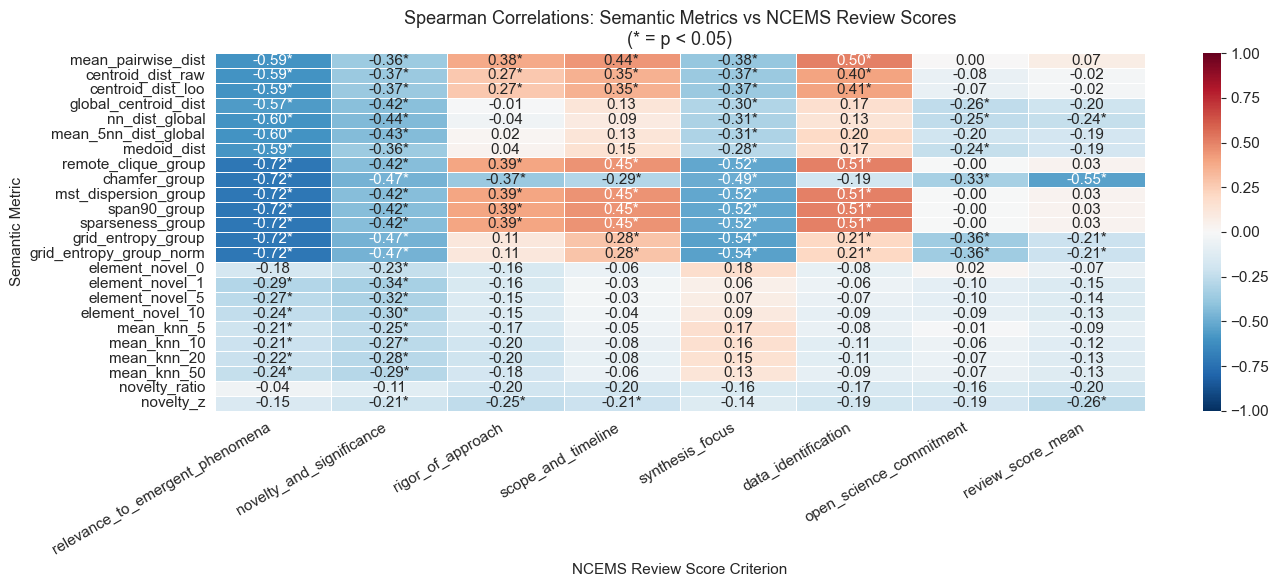

                         relevance_to_emergent_phenomena  \
mean_pairwise_dist                                -0.595   
centroid_dist_raw                                 -0.595   
centroid_dist_loo                                 -0.595   
global_centroid_dist                              -0.566   
nn_dist_global                                    -0.597   
mean_5nn_dist_global                              -0.596   
medoid_dist                                       -0.593   
remote_clique_group                               -0.722   
chamfer_group                                     -0.722   
mst_dispersion_group                              -0.722   
span90_group                                      -0.722   
sparseness_group                                  -0.722   
grid_entropy_group                                -0.722   
grid_entropy_group_norm                           -0.722   
element_novel_0                                   -0.175   
element_novel_1                         

In [96]:
# --- Semantic metrics vs NCEMS scores ---
corr_sem_ncems = compute_corr_matrix(df, SEMANTIC_METRICS, NCEMS_SCORES)
pval_sem_ncems = compute_pval_matrix(df, SEMANTIC_METRICS, NCEMS_SCORES)

fig, ax = plt.subplots(figsize=(14, 6))

annot = corr_sem_ncems.round(2).astype(str)
for m in SEMANTIC_METRICS:
    for s in NCEMS_SCORES:
        r = corr_sem_ncems.loc[m, s]
        p = pval_sem_ncems.loc[m, s]
        annot.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}"

sns.heatmap(
    corr_sem_ncems, annot=annot, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlations: Semantic Metrics vs NCEMS Review Scores\n(* = p < 0.05)', fontsize=13)
ax.set_xlabel('NCEMS Review Score Criterion')
ax.set_ylabel('Semantic Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_semantic_ncems.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_sem_ncems.round(3))

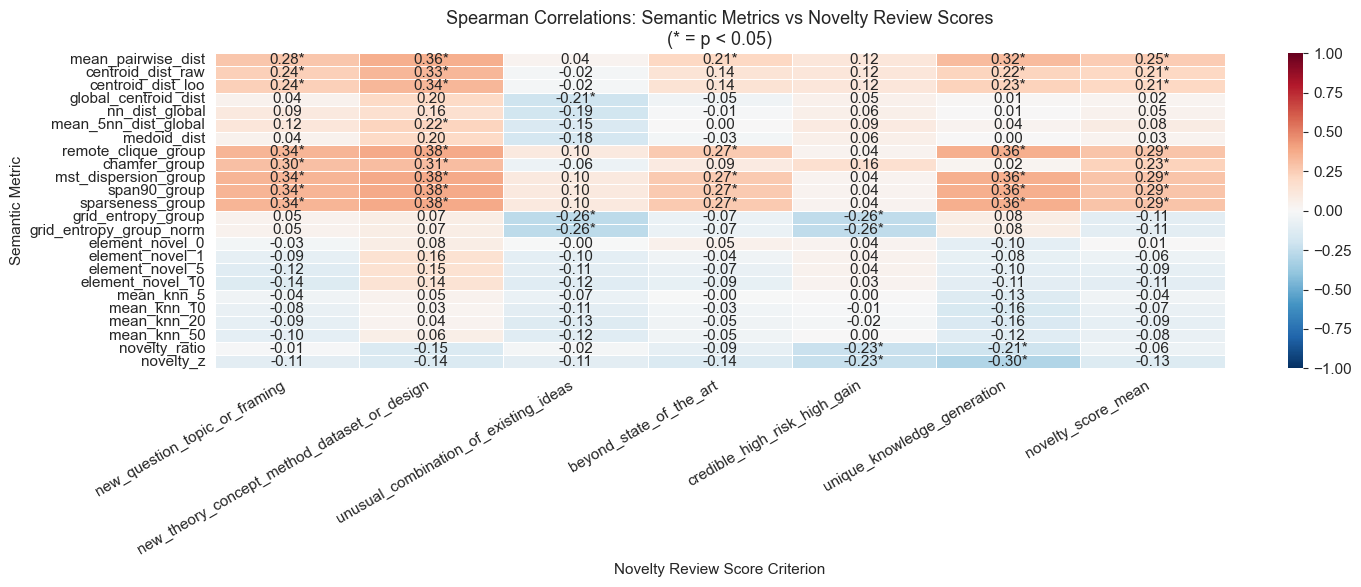

                         new_question_topic_or_framing  \
mean_pairwise_dist                               0.278   
centroid_dist_raw                                0.236   
centroid_dist_loo                                0.238   
global_centroid_dist                             0.043   
nn_dist_global                                   0.095   
mean_5nn_dist_global                             0.117   
medoid_dist                                      0.041   
remote_clique_group                              0.343   
chamfer_group                                    0.300   
mst_dispersion_group                             0.343   
span90_group                                     0.343   
sparseness_group                                 0.343   
grid_entropy_group                               0.046   
grid_entropy_group_norm                          0.046   
element_novel_0                                 -0.028   
element_novel_1                                 -0.092   
element_novel_

In [97]:
# --- Semantic metrics vs Novelty scores ---
corr_sem_nov = compute_corr_matrix(df, SEMANTIC_METRICS, NOVELTY_SCORES)
pval_sem_nov = compute_pval_matrix(df, SEMANTIC_METRICS, NOVELTY_SCORES)

fig, ax = plt.subplots(figsize=(15, 6))

annot2 = corr_sem_nov.round(2).astype(str)
for m in SEMANTIC_METRICS:
    for s in NOVELTY_SCORES:
        r = corr_sem_nov.loc[m, s]
        p = pval_sem_nov.loc[m, s]
        annot2.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}"

sns.heatmap(
    corr_sem_nov, annot=annot2, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlations: Semantic Metrics vs Novelty Review Scores\n(* = p < 0.05)', fontsize=13)
ax.set_xlabel('Novelty Review Score Criterion')
ax.set_ylabel('Semantic Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_semantic_novelty.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_sem_nov.round(3))

### b) Human reviews (y2) vs metric

Human-Y2 prepared score table: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/human_y2_scores_wide.csv
Y2 human proposals used for Human-Y2 metric-score analysis: 11
Analysis dataframe shape: (11, 66)

Metrics with per-proposal variation: 17 / 24
Dropped (group-level constants, NaN correlation): ['remote_clique_group', 'chamfer_group', 'mst_dispersion_group', 'span90_group', 'sparseness_group', 'grid_entropy_group', 'grid_entropy_group_norm']


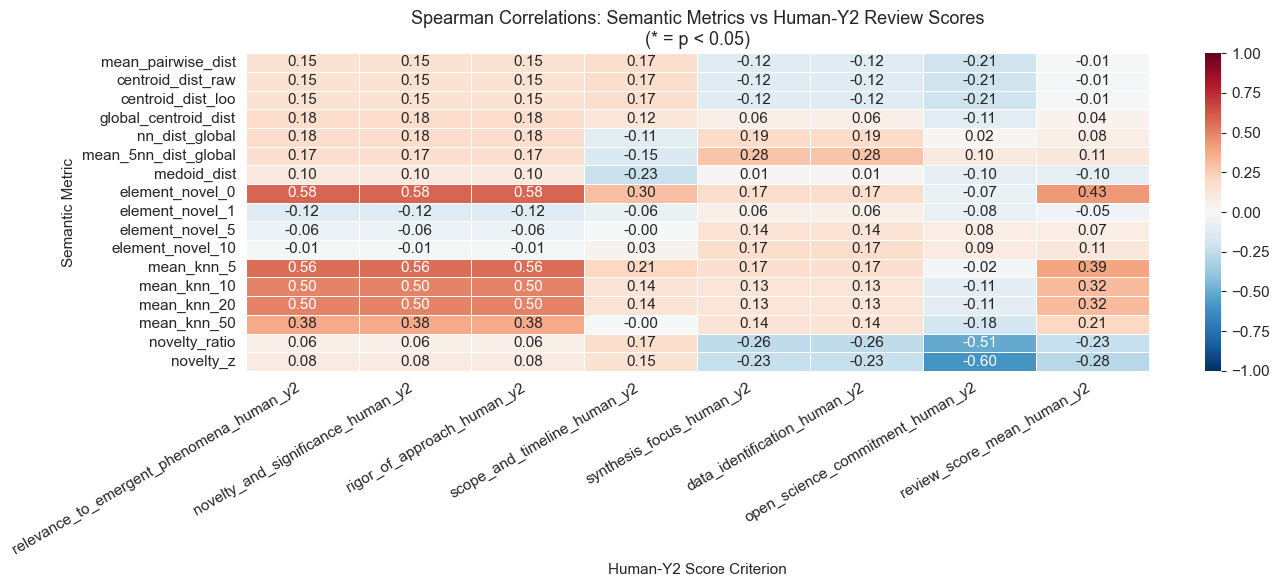

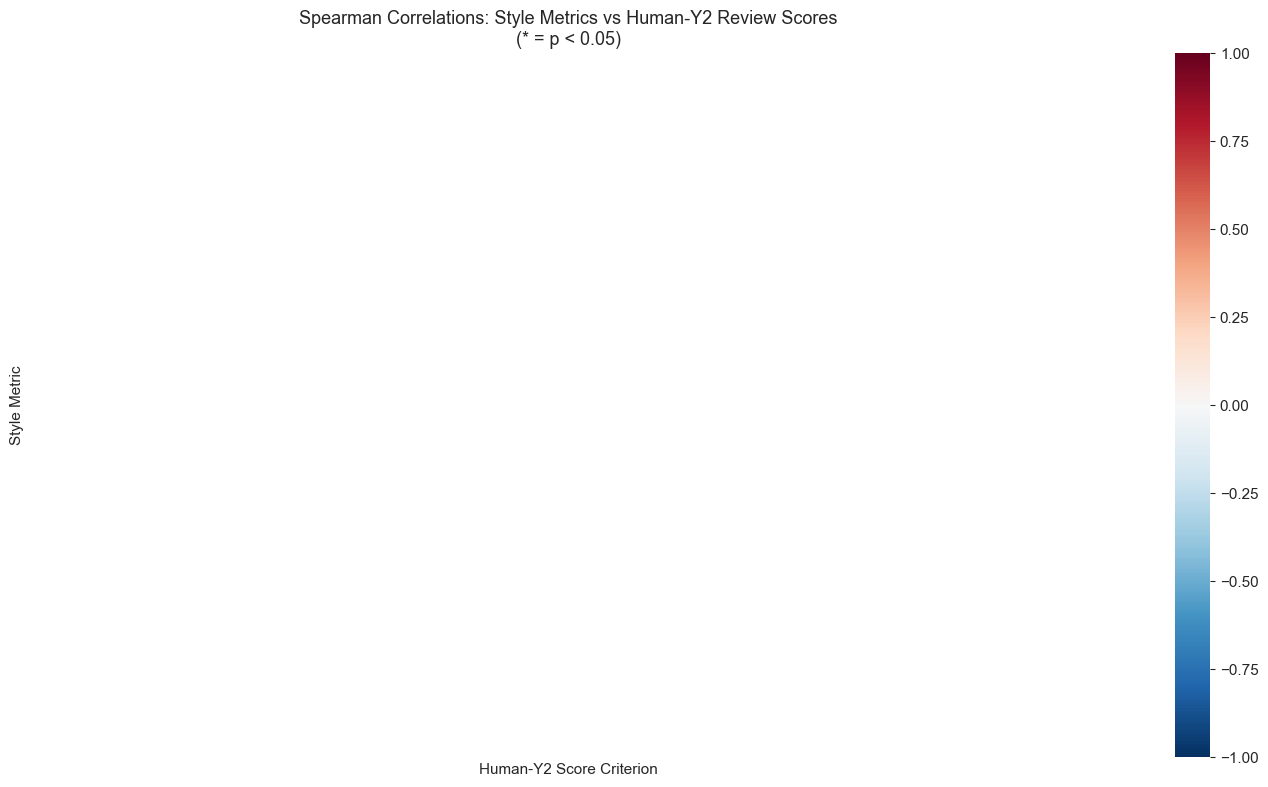


Top 15 correlations — Semantic vs Human-Y2


,metric,score,spearman_r,p_value,sig
0,novelty_z,open_science_commitment_human_y2,-0.5968,0.0526,
1,element_novel_0,rigor_of_approach_human_y2,0.5807,0.0610,
2,element_novel_0,novelty_and_significance_human_y2,0.5807,0.0610,
3,element_novel_0,relevance_to_emergent_phenomena_human_y2,0.5807,0.0610,
4,mean_knn_5,relevance_to_emergent_phenomena_human_y2,0.5623,0.0718,
5,mean_knn_5,novelty_and_significance_human_y2,0.5623,0.0718,
6,mean_knn_5,rigor_of_approach_human_y2,0.5623,0.0718,
7,novelty_ratio,open_science_commitment_human_y2,-0.5148,0.1051,
8,mean_knn_20,rigor_of_approach_human_y2,0.4977,0.1192,
9,mean_knn_10,relevance_to_emergent_phenomena_human_y2,0.4977,0.1192,



Top 15 correlations — Style vs Human-Y2  (no metrics available)


,metric,score,spearman_r,p_value,sig


,metric,score,spearman_r,p_value
0,novelty_z,open_science_commitment_human_y2,-0.5968,0.0526
1,element_novel_0,rigor_of_approach_human_y2,0.5807,0.0610
2,element_novel_0,novelty_and_significance_human_y2,0.5807,0.0610
3,element_novel_0,relevance_to_emergent_phenomena_human_y2,0.5807,0.0610
4,mean_knn_5,relevance_to_emergent_phenomena_human_y2,0.5623,0.0718
5,mean_knn_5,novelty_and_significance_human_y2,0.5623,0.0718


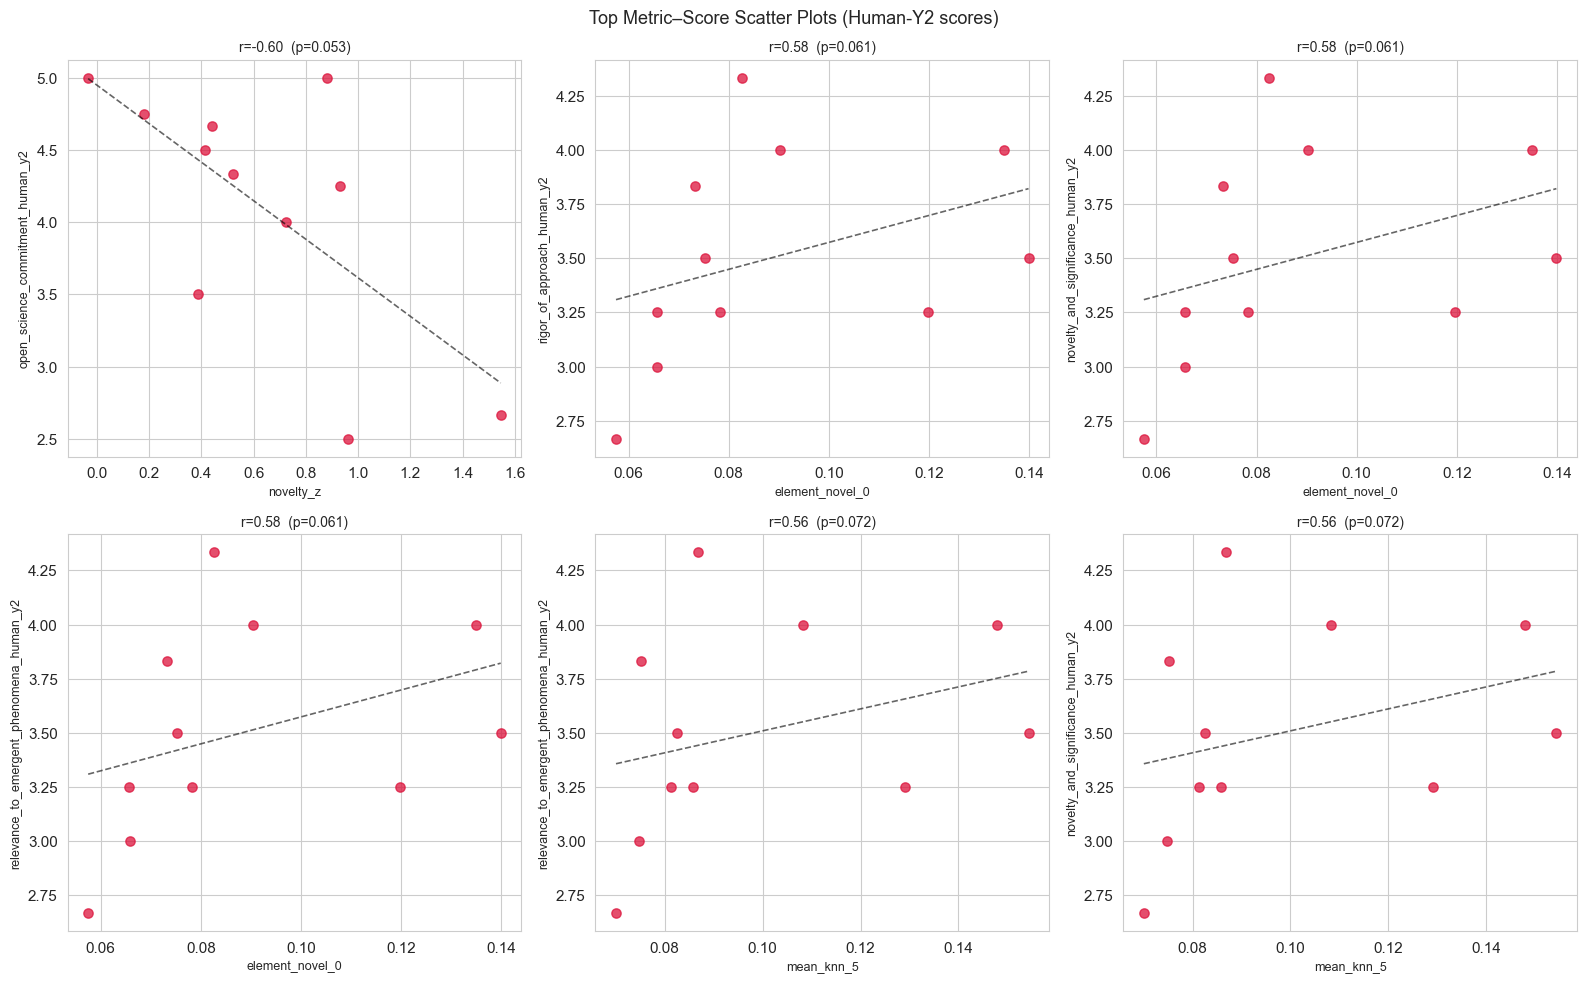

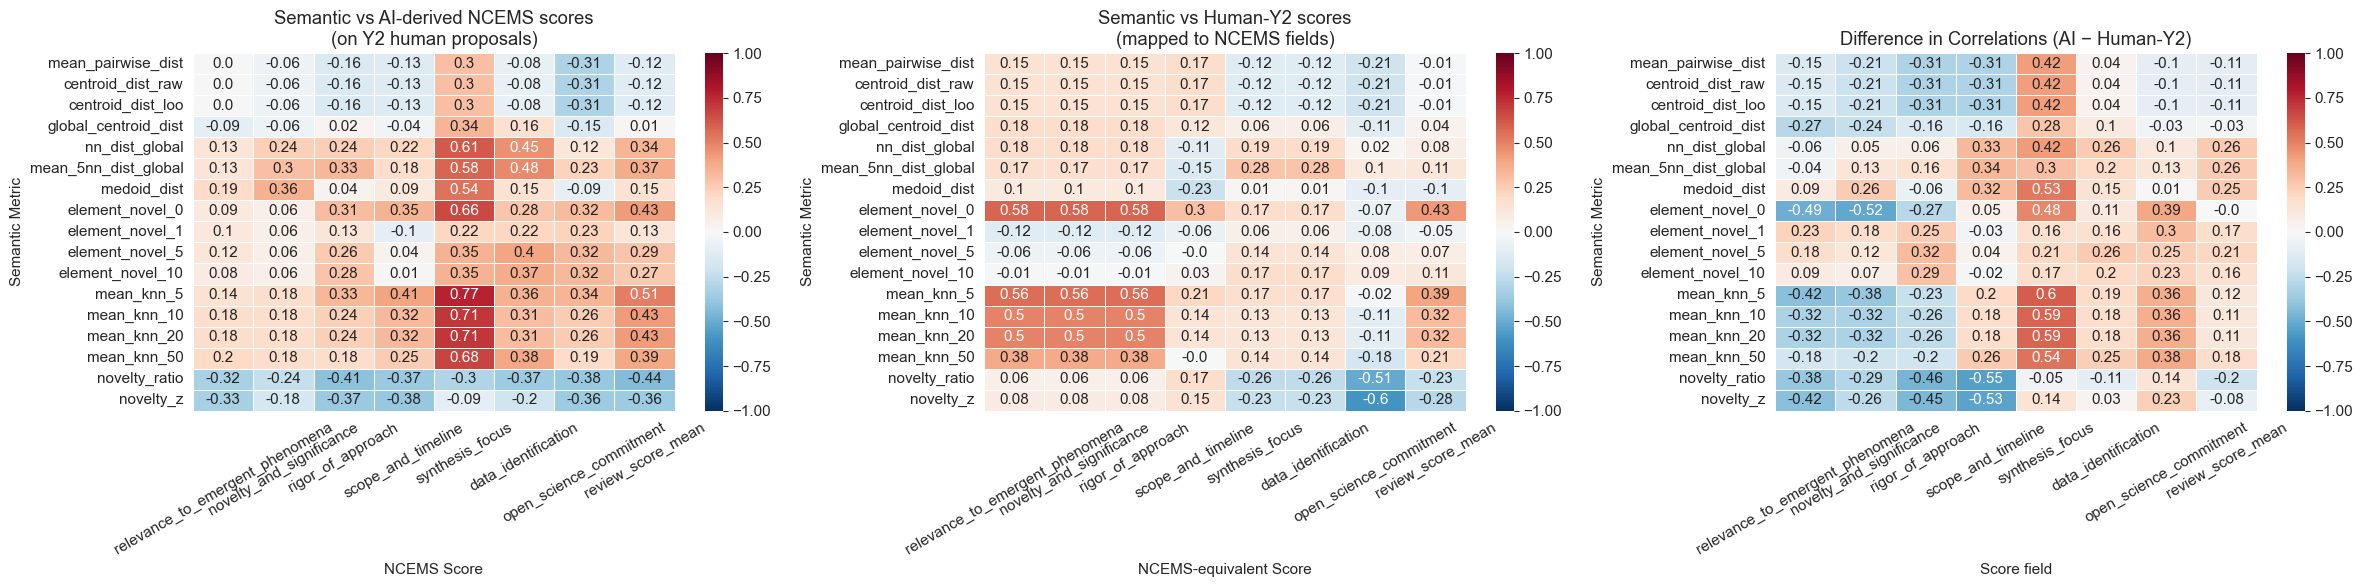

Saved Human-Y2 metric-score outputs to:
- /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/metric-score/spearman_corr_semantic_human_y2_scores.csv
- /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/metric-score/spearman_pval_semantic_human_y2_scores.csv
- /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/metric-score/spearman_corr_style_human_y2_scores.csv
- /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/metric-score/spearman_pval_style_human_y2_scores.csv
- /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/metric-score/spearman_corr_diff_semantic_ai_minus_humany2_on_y2.csv
- /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/metric-score/spearman_corr_semantic_ai_scores_on_y2_human_proposals.csv


In [98]:
# Local title normalization helper for robust merges.
if 'normalize_title' not in globals():
    import re

    def normalize_title(title):
        if pd.isna(title):
            return ''
        t = str(title).strip().lower()
        t = re.sub(r'\s+', ' ', t)
        t = re.sub(r'[^a-z0-9 ]', '', t)
        return t

# --- Use prepared Human-Y2 score means (no re-aggregation in this notebook) ---
HUMAN_Y2_SCORE_COLS = [
    'relevance_to_emergent_phenomena_human_y2',
    'novelty_and_significance_human_y2',
    'rigor_of_approach_human_y2',
    'scope_and_timeline_human_y2',
    'synthesis_focus_human_y2',
    'data_identification_human_y2',
    'open_science_commitment_human_y2',
    'review_score_mean_human_y2',
]

# Restrict to human proposals in Y2 cohort.
df_human_y2 = df[(df['is_ai'] == False) & (df['cohort'].astype(str).str.lower() == 'y2')].copy()

missing_hy2_in_df = [c for c in HUMAN_Y2_SCORE_COLS if c not in df_human_y2.columns]
if missing_hy2_in_df:
    raise KeyError(
        f'Missing Human-Y2 score columns in merged DataFrame: {missing_hy2_in_df}. '
        'Ensure prepare_data_for_analysis.ipynb was re-run and outputs are current.'
    )

print('Human-Y2 prepared score table:', HUMAN_Y2_SCORES_WIDE_PATH)
print('Y2 human proposals used for Human-Y2 metric-score analysis:', df_human_y2['title'].nunique())
print('Analysis dataframe shape:', df_human_y2.shape)

# --- Filter to per-proposal metrics only ---
# Group-level metrics (remote_clique_group, chamfer_group, mst_dispersion_group,
# span90_group, sparseness_group, grid_entropy_group*, mean_pairwise_dist, medoid_dist)
# are aggregates: all proposals in the same group share the same value.
# A constant column produces NaN Spearman correlation, so we exclude these.
valid_sem_metrics = [
    m for m in SEMANTIC_METRICS
    if m in df_human_y2.columns and df_human_y2[m].dropna().std() > 1e-10
]
dropped = [m for m in SEMANTIC_METRICS if m not in valid_sem_metrics]
print(f'\nMetrics with per-proposal variation: {len(valid_sem_metrics)} / {len(SEMANTIC_METRICS)}')
if dropped:
    print(f'Dropped (group-level constants, NaN correlation): {dropped}')

# --- Correlation: per-proposal semantic metrics vs Human-Y2 scores ---
corr_sem_hy2 = compute_corr_matrix(df_human_y2, valid_sem_metrics, HUMAN_Y2_SCORE_COLS)
pval_sem_hy2 = compute_pval_matrix(df_human_y2, valid_sem_metrics, HUMAN_Y2_SCORE_COLS)

fig, ax = plt.subplots(figsize=(14, 6))
annot_hy2 = corr_sem_hy2.round(2).astype(str)
for m in valid_sem_metrics:
    for s in HUMAN_Y2_SCORE_COLS:
        r = corr_sem_hy2.loc[m, s]
        p = pval_sem_hy2.loc[m, s]
        annot_hy2.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}" if pd.notna(r) else ''

sns.heatmap(
    corr_sem_hy2, annot=annot_hy2, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlations: Semantic Metrics vs Human-Y2 Review Scores\n(* = p < 0.05)', fontsize=13)
ax.set_xlabel('Human-Y2 Score Criterion')
ax.set_ylabel('Semantic Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_semantic_human_y2.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Correlation: style metrics vs Human-Y2 scores ---
corr_sty_hy2 = compute_corr_matrix(df_human_y2, STYLE_METRICS, HUMAN_Y2_SCORE_COLS)
pval_sty_hy2 = compute_pval_matrix(df_human_y2, STYLE_METRICS, HUMAN_Y2_SCORE_COLS)

fig, ax = plt.subplots(figsize=(14, 8))
annot_sty_hy2 = corr_sty_hy2.round(2).astype(str)
for m in STYLE_METRICS:
    for s in HUMAN_Y2_SCORE_COLS:
        r = corr_sty_hy2.loc[m, s]
        p = pval_sty_hy2.loc[m, s]
        annot_sty_hy2.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}" if pd.notna(r) else ''

sns.heatmap(
    corr_sty_hy2, annot=annot_sty_hy2, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlations: Style Metrics vs Human-Y2 Review Scores\n(* = p < 0.05)', fontsize=13)
ax.set_xlabel('Human-Y2 Score Criterion')
ax.set_ylabel('Style Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_style_human_y2.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Strongest correlation summaries (Human-Y2) ---
top_sem_hy2 = top_correlations(corr_sem_hy2, pval_sem_hy2, n=15, label='Semantic vs Human-Y2')
display(top_sem_hy2.round(4))

top_sty_hy2 = top_correlations(corr_sty_hy2, pval_sty_hy2, n=15, label='Style vs Human-Y2')
display(top_sty_hy2.round(4))

# --- Scatter plots: top metric-score pairs for Human-Y2 ---
all_corrs_hy2 = (
    pd.concat([
        top_sem_hy2[['metric', 'score', 'spearman_r', 'p_value']],
        top_sty_hy2[['metric', 'score', 'spearman_r', 'p_value']],
    ])
    .sort_values('spearman_r', key=abs, ascending=False)
    .drop_duplicates(subset=['metric', 'score'])
)

top_pairs_hy2 = all_corrs_hy2.head(6)
display(top_pairs_hy2.round(4))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (_, row) in zip(axes.flat, top_pairs_hy2.iterrows()):
    m, s, r, p = row['metric'], row['score'], row['spearman_r'], row['p_value']
    subset = df_human_y2[[m, s]].dropna()

    ax.scatter(subset[m], subset[s], color=colors.get('Human', 'gray'), alpha=0.75, s=45)

    if len(subset) >= 2:
        z = np.polyfit(subset[m].values, subset[s].values, 1)
        x_sorted = np.sort(subset[m].values)
        ax.plot(x_sorted, np.poly1d(z)(x_sorted), 'k--', linewidth=1.2, alpha=0.6)

    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    ax.set_xlabel(m, fontsize=9)
    ax.set_ylabel(s, fontsize=9)
    ax.set_title(f'r={r:.2f} {sig} (p={p:.3f})', fontsize=10)

plt.suptitle('Top Metric–Score Scatter Plots (Human-Y2 scores)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_scatter_metric_score_human_y2.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Direct comparison: AI review scores vs Human-Y2 scores on the same Y2 human proposals ---
# Use the same valid_sem_metrics so both panels have the same rows.
ai_ncems_cols = NCEMS_SCORES
human_y2_to_ai_map = {
    'relevance_to_emergent_phenomena_human_y2': 'relevance_to_emergent_phenomena',
    'novelty_and_significance_human_y2':        'novelty_and_significance',
    'rigor_of_approach_human_y2':               'rigor_of_approach',
    'scope_and_timeline_human_y2':              'scope_and_timeline',
    'synthesis_focus_human_y2':                 'synthesis_focus',
    'data_identification_human_y2':             'data_identification',
    'open_science_commitment_human_y2':         'open_science_commitment',
    'review_score_mean_human_y2':               'review_score_mean',
}

corr_sem_ai_on_y2 = compute_corr_matrix(df_human_y2, valid_sem_metrics, ai_ncems_cols)
corr_sem_hy2_as_ai = corr_sem_hy2.rename(columns=human_y2_to_ai_map)

aligned_cols = [c for c in ai_ncems_cols if c in corr_sem_hy2_as_ai.columns]
diff_sem_y2 = corr_sem_ai_on_y2[aligned_cols] - corr_sem_hy2_as_ai[aligned_cols]

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.heatmap(corr_sem_ai_on_y2[aligned_cols], annot=corr_sem_ai_on_y2[aligned_cols].round(2), fmt='',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=axes[0])
axes[0].set_title('Semantic vs AI-derived NCEMS scores\n(on Y2 human proposals)')
axes[0].set_xlabel('NCEMS Score')
axes[0].set_ylabel('Semantic Metric')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(corr_sem_hy2_as_ai[aligned_cols], annot=corr_sem_hy2_as_ai[aligned_cols].round(2), fmt='',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=axes[1])
axes[1].set_title('Semantic vs Human-Y2 scores\n(mapped to NCEMS fields)')
axes[1].set_xlabel('NCEMS-equivalent Score')
axes[1].set_ylabel('Semantic Metric')
axes[1].tick_params(axis='x', rotation=30)

sns.heatmap(diff_sem_y2, annot=diff_sem_y2.round(2), fmt='',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=axes[2])
axes[2].set_title('Difference in Correlations (AI − Human-Y2)')
axes[2].set_xlabel('Score field')
axes[2].set_ylabel('Semantic Metric')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_semantic_ai_vs_humany2_on_y2.png', dpi=150, bbox_inches='tight')
plt.show()

# Save Human-Y2-specific correlation tables.
corr_sem_hy2.round(4).to_csv(TABLES_DIR / 'spearman_corr_semantic_human_y2_scores.csv')
pval_sem_hy2.round(6).to_csv(TABLES_DIR / 'spearman_pval_semantic_human_y2_scores.csv')
corr_sty_hy2.round(4).to_csv(TABLES_DIR / 'spearman_corr_style_human_y2_scores.csv')
pval_sty_hy2.round(6).to_csv(TABLES_DIR / 'spearman_pval_style_human_y2_scores.csv')
diff_sem_y2.round(4).to_csv(TABLES_DIR / 'spearman_corr_diff_semantic_ai_minus_humany2_on_y2.csv')

# Also export AI-score correlations on this same Y2 human-proposal subset for direct paired interpretation.
corr_sem_ai_on_y2.round(4).to_csv(TABLES_DIR / 'spearman_corr_semantic_ai_scores_on_y2_human_proposals.csv')

print('Saved Human-Y2 metric-score outputs to:')
print('-', TABLES_DIR / 'spearman_corr_semantic_human_y2_scores.csv')
print('-', TABLES_DIR / 'spearman_pval_semantic_human_y2_scores.csv')
print('-', TABLES_DIR / 'spearman_corr_style_human_y2_scores.csv')
print('-', TABLES_DIR / 'spearman_pval_style_human_y2_scores.csv')
print('-', TABLES_DIR / 'spearman_corr_diff_semantic_ai_minus_humany2_on_y2.csv')
print('-', TABLES_DIR / 'spearman_corr_semantic_ai_scores_on_y2_human_proposals.csv')


## 3. Strongest Correlations Summary

Report the top metric–score pairs by absolute Spearman r, with p-values.

In [99]:
def top_correlations(corr_df, pval_df, n=15, label=''):
    records = []
    for metric in corr_df.index:
        for score in corr_df.columns:
            r = corr_df.loc[metric, score]
            p = pval_df.loc[metric, score]
            if not np.isnan(r):
                records.append({'metric': metric, 'score': score, 'spearman_r': r, 'p_value': p})
    result = (
        pd.DataFrame(records)
        .sort_values('spearman_r', key=abs, ascending=False)
        .head(n)
    )
    result['sig'] = result['p_value'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    )
    print(f"\nTop {n} correlations — {label}")
    return result.reset_index(drop=True)

top_sem_ncems = top_correlations(corr_sem_ncems, pval_sem_ncems, n=15, label='Semantic vs NCEMS')
display(top_sem_ncems.round(4))

top_sem_nov = top_correlations(corr_sem_nov, pval_sem_nov, n=15, label='Semantic vs Novelty')
display(top_sem_nov.round(4))


Top 15 correlations — Semantic vs NCEMS


,metric,score,spearman_r,p_value,sig
0,grid_entropy_group,relevance_to_emergent_phenomena,-0.7220,0.0,***
1,grid_entropy_group_norm,relevance_to_emergent_phenomena,-0.7220,0.0,***
2,sparseness_group,relevance_to_emergent_phenomena,-0.7220,0.0,***
3,span90_group,relevance_to_emergent_phenomena,-0.7220,0.0,***
4,mst_dispersion_group,relevance_to_emergent_phenomena,-0.7220,0.0,***
5,chamfer_group,relevance_to_emergent_phenomena,-0.7220,0.0,***
6,remote_clique_group,relevance_to_emergent_phenomena,-0.7220,0.0,***
7,nn_dist_global,relevance_to_emergent_phenomena,-0.5973,0.0,***
8,mean_5nn_dist_global,relevance_to_emergent_phenomena,-0.5958,0.0,***
9,centroid_dist_loo,relevance_to_emergent_phenomena,-0.5945,0.0,***



Top 15 correlations — Semantic vs Novelty


,metric,score,spearman_r,p_value,sig
0,mst_dispersion_group,new_theory_concept_method_dataset_or_design,0.3779,0.0002,***
1,sparseness_group,new_theory_concept_method_dataset_or_design,0.3779,0.0002,***
2,remote_clique_group,new_theory_concept_method_dataset_or_design,0.3779,0.0002,***
3,span90_group,new_theory_concept_method_dataset_or_design,0.3779,0.0002,***
4,sparseness_group,unique_knowledge_generation,0.3646,0.0004,***
5,mst_dispersion_group,unique_knowledge_generation,0.3646,0.0004,***
6,span90_group,unique_knowledge_generation,0.3646,0.0004,***
7,remote_clique_group,unique_knowledge_generation,0.3646,0.0004,***
8,mean_pairwise_dist,new_theory_concept_method_dataset_or_design,0.3646,0.0004,***
9,sparseness_group,new_question_topic_or_framing,0.3433,0.0008,***



## 4. Outlier Validation: Do Semantically Unique Proposals Score Higher?

We test whether proposals flagged as outliers (`is_outlier`, `is_most_novel_raw`, etc., including `is_literature_outlier`) receive significantly higher review scores using Mann-Whitney U tests.


In [100]:
def outlier_score_comparison(df, flag_col, score_cols, title=''):
    """Mann-Whitney U test comparing flagged vs non-flagged proposals."""
    if flag_col not in df.columns:
        print(f"\n{title}  (column '{flag_col}' not in df — skipped)")
        return pd.DataFrame()
    df_sub      = df.dropna(subset=[flag_col])
    flagged     = df_sub[df_sub[flag_col] == True]
    not_flagged = df_sub[df_sub[flag_col] == False]
    print(f"\n{title}")
    print(f"  Flagged: {len(flagged)} | Not flagged: {len(not_flagged)}")

    results = []
    for s in score_cols:
        x = flagged[s].dropna()
        y = not_flagged[s].dropna()
        if len(x) < 2 or len(y) < 2:
            continue
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
        results.append({
            'score':            s,
            'flagged_mean':     x.mean(),
            'not_flagged_mean': y.mean(),
            'diff':             x.mean() - y.mean(),
            'U':                stat,
            'p_value':          p,
            'sig':              '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')),
        })
    return pd.DataFrame(results).sort_values('p_value')


# NCEMS scores
print("=" * 60)
print("NCEMS Review Scores")
for flag in OUTLIER_FLAGS:
    res = outlier_score_comparison(df, flag, NCEMS_SCORES, title=f'Flag: {flag}')
    if not res.empty:
        display(res.round(4))

print("\n" + "=" * 60)
print("Novelty Review Scores")
for flag in OUTLIER_FLAGS:
    res = outlier_score_comparison(df, flag, NOVELTY_SCORES, title=f'Flag: {flag}')
    if not res.empty:
        display(res.round(4))

NCEMS Review Scores

Flag: is_outlier  (column 'is_outlier' not in df — skipped)

Flag: is_most_novel_raw  (column 'is_most_novel_raw' not in df — skipped)

Flag: is_most_novel_z  (column 'is_most_novel_z' not in df — skipped)

Flag: is_most_novel_ratio  (column 'is_most_novel_ratio' not in df — skipped)

Flag: is_literature_outlier  (column 'is_literature_outlier' not in df — skipped)

Flag: is_lit_outlier_mean10
  Flagged: 10 | Not flagged: 82


,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
0,relevance_to_emergent_phenomena,3.8000,4.7967,-0.9967,187.5,0.0002,***
1,novelty_and_significance,4.0667,4.3089,-0.2423,228.0,0.0002,***
7,review_score_mean,3.6700,3.9683,-0.2983,206.0,0.0104,*
6,open_science_commitment,3.7000,4.2073,-0.5073,254.0,0.0397,*
2,rigor_of_approach,3.5333,3.8049,-0.2715,310.0,0.1950,
3,scope_and_timeline,2.9667,3.0732,-0.1065,324.5,0.2604,
5,data_identification,3.4000,3.5732,-0.1732,328.5,0.2946,
4,synthesis_focus,4.8333,4.8537,-0.0203,389.0,0.6806,



Flag: is_lit_outlier_element0
  Flagged: 10 | Not flagged: 82


,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
0,relevance_to_emergent_phenomena,3.9000,4.7846,-0.8846,232.5,0.0025,**
1,novelty_and_significance,4.1000,4.3049,-0.2049,271.0,0.0041,**
7,review_score_mean,3.6733,3.9679,-0.2946,209.5,0.0118,*
6,open_science_commitment,3.7000,4.2073,-0.5073,254.0,0.0397,*
5,data_identification,3.3333,3.5813,-0.2480,294.5,0.1368,
2,rigor_of_approach,3.5333,3.8049,-0.2715,310.0,0.1950,
3,scope_and_timeline,2.9667,3.0732,-0.1065,324.5,0.2604,
4,synthesis_focus,4.8333,4.8537,-0.0203,389.0,0.6806,



Flag: is_lit_outlier_z
  Flagged: 10 | Not flagged: 82


...

,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
2,unusual_combination_of_existing_ideas,4.1667,4.3699,-0.2033,259.0,0.0504,
5,unique_knowledge_generation,3.9333,4.1138,-0.1805,288.5,0.1042,
0,new_question_topic_or_framing,3.5000,3.7073,-0.2073,309.5,0.1991,
6,novelty_score_mean,3.6233,3.7142,-0.0909,324.5,0.2852,
3,beyond_state_of_the_art,3.4667,3.5467,-0.0801,349.5,0.4368,
4,credible_high_risk_high_gain,3.5333,3.5508,-0.0175,361.5,0.4820,
1,new_theory_concept_method_dataset_or_design,3.4667,3.3740,0.0927,436.0,0.7368,



Flag: is_lit_outlier_element0
  Flagged: 10 | Not flagged: 82


,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
5,unique_knowledge_generation,3.9000,4.1179,-0.2179,252.0,0.0344,*
0,new_question_topic_or_framing,3.4333,3.7154,-0.2821,267.5,0.0682,
2,unusual_combination_of_existing_ideas,4.2000,4.3659,-0.1659,288.5,0.1156,
6,novelty_score_mean,3.6067,3.7163,-0.1096,303.5,0.1826,
4,credible_high_risk_high_gain,3.5000,3.5549,-0.0549,326.5,0.2241,
3,beyond_state_of_the_art,3.4667,3.5467,-0.0801,349.5,0.4368,
1,new_theory_concept_method_dataset_or_design,3.4333,3.3780,0.0553,410.5,1.0000,



Flag: is_lit_outlier_z
  Flagged: 10 | Not flagged: 82


,score,flagged_mean,not_flagged_mean,diff,U,p_value,sig
5,unique_knowledge_generation,3.8833,4.1199,-0.2366,254.5,0.0374,*
0,new_question_topic_or_framing,3.4667,3.7114,-0.2447,292.0,0.1313,
6,novelty_score_mean,3.6117,3.7157,-0.1040,307.0,0.1975,
2,unusual_combination_of_existing_ideas,4.2167,4.3638,-0.1472,321.5,0.2525,
3,beyond_state_of_the_art,3.4000,3.5549,-0.1549,322.0,0.2568,
1,new_theory_concept_method_dataset_or_design,3.3500,3.3882,-0.0382,365.0,0.5575,
4,credible_high_risk_high_gain,3.5667,3.5467,0.0199,396.0,0.8432,


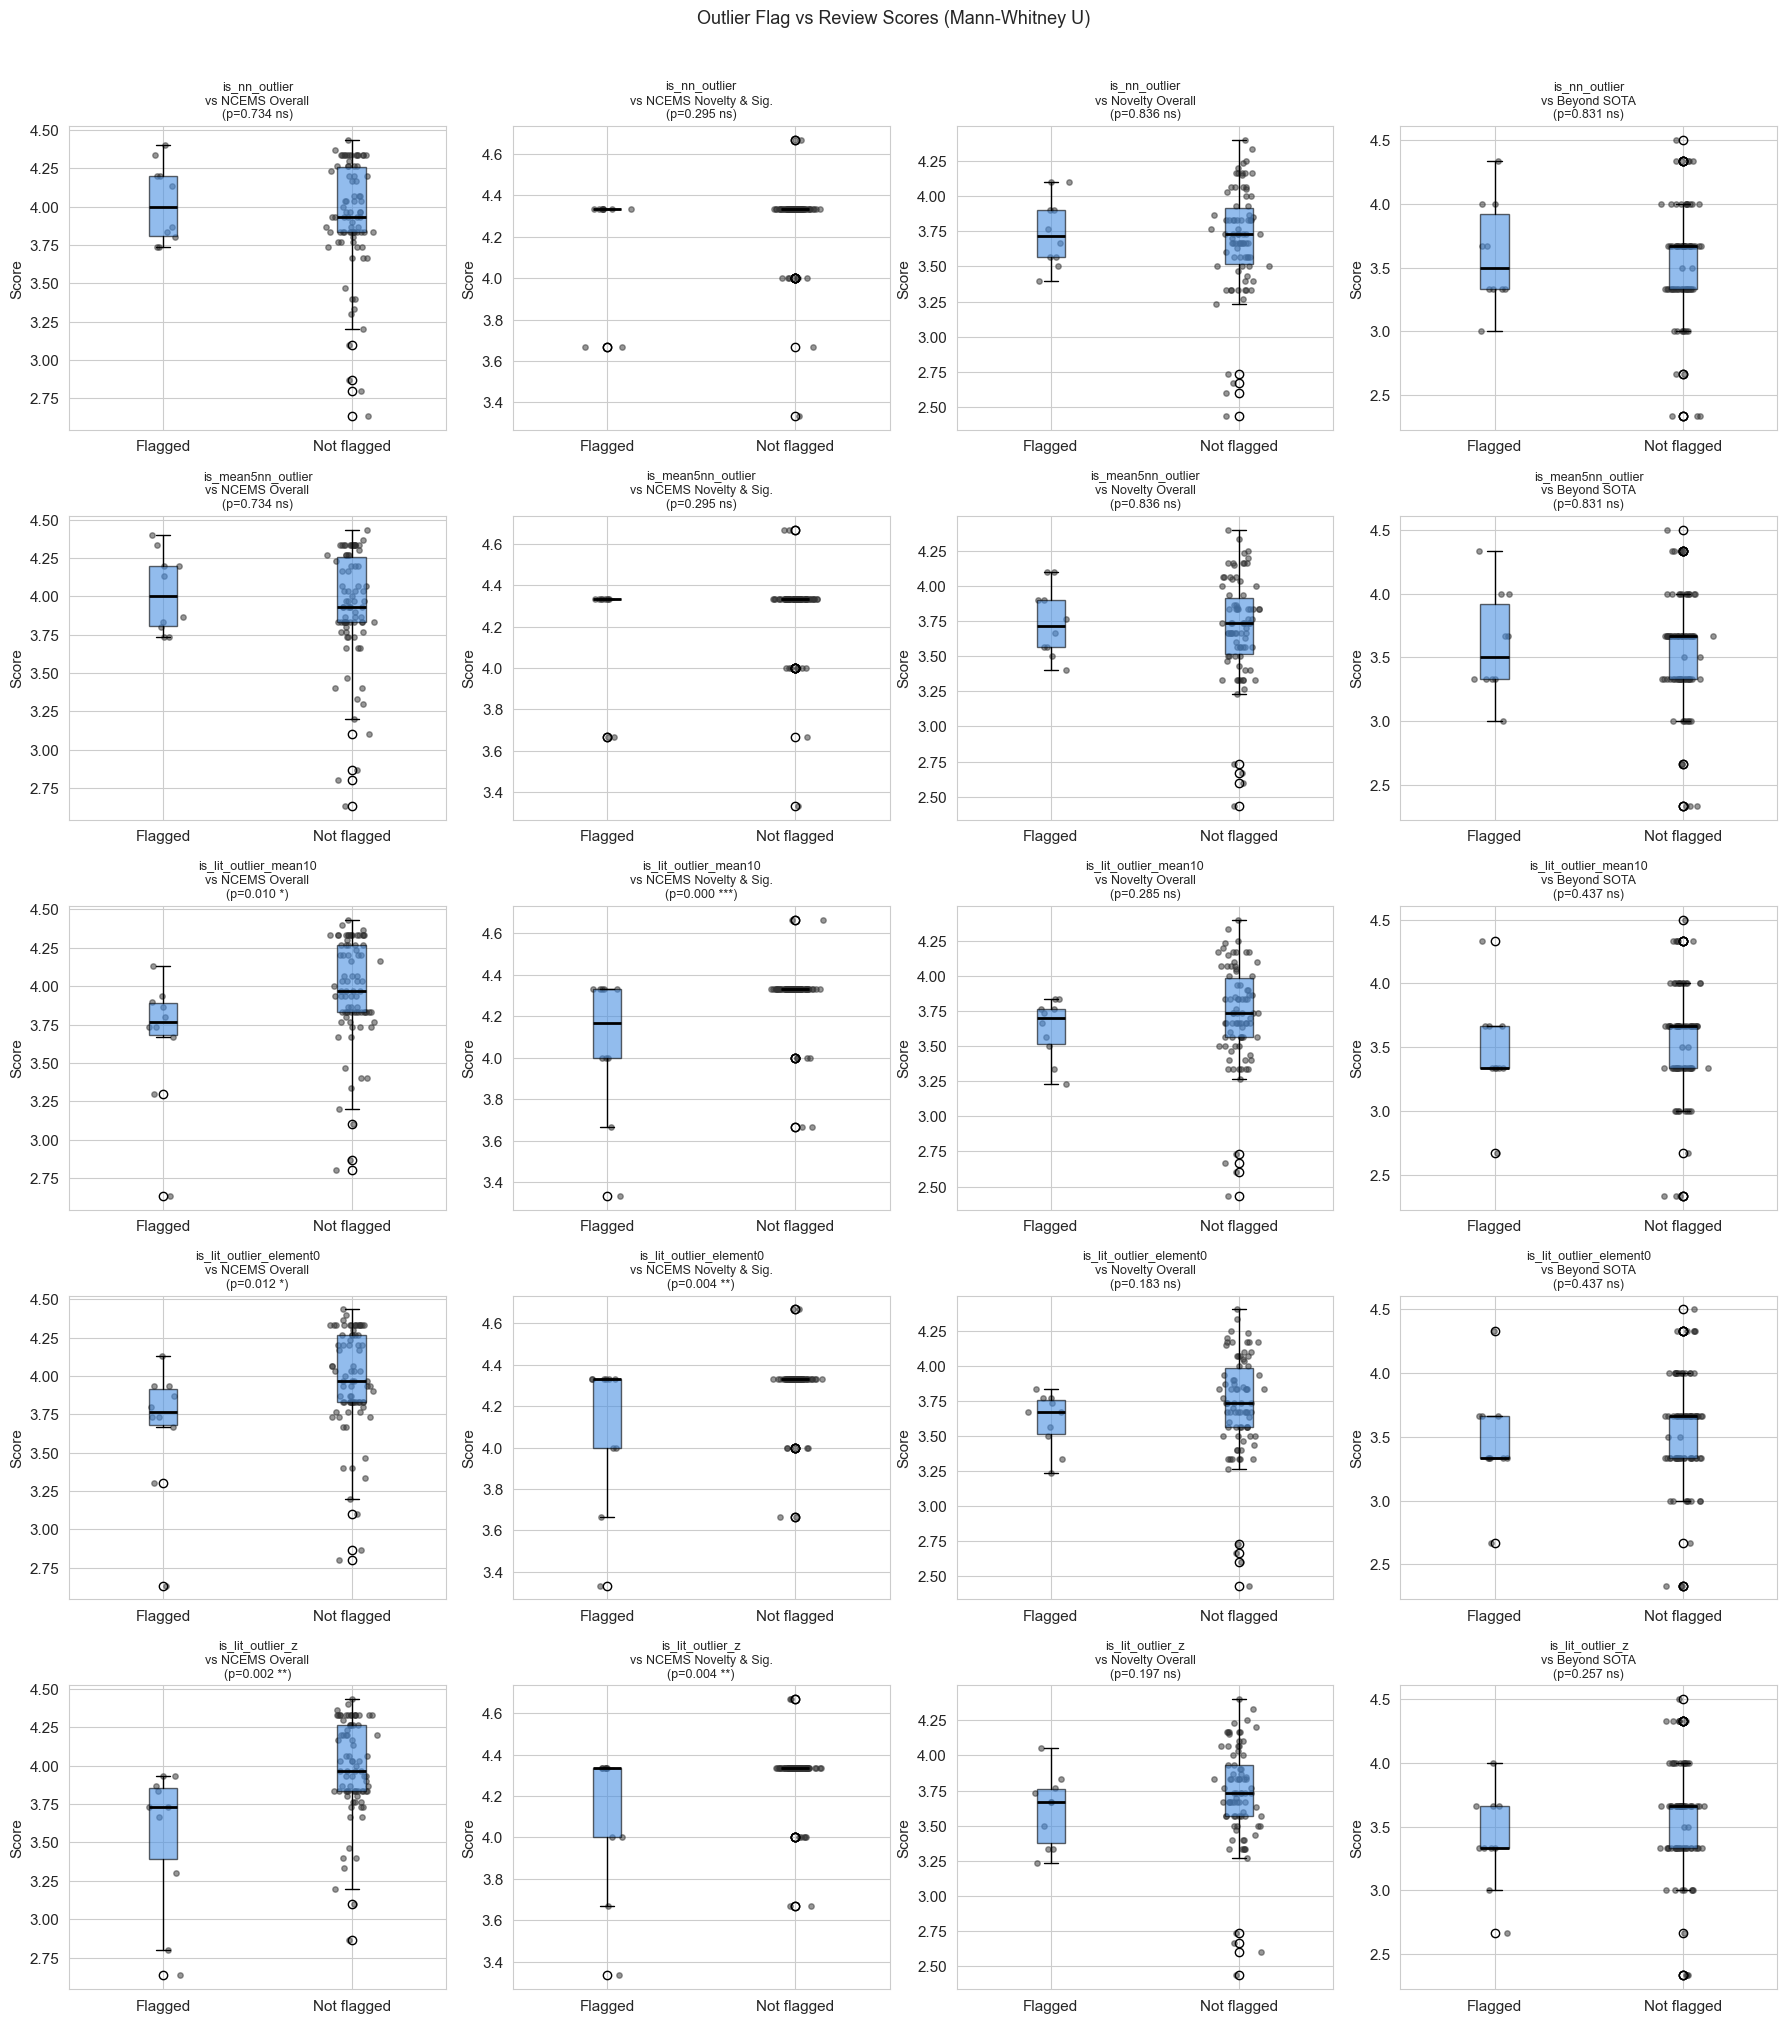

In [101]:
# Box-plots: outlier flags vs key review scores
score_labels = {
    'review_score_mean': 'NCEMS Overall',
    'novelty_and_significance': 'NCEMS Novelty & Sig.',
    'novelty_score_mean': 'Novelty Overall',
    'beyond_state_of_the_art': 'Beyond SOTA',
}

# Select plotting flags from whichever names are actually present in df.
# Prefer: intra-proposal-space outlier, then literature-space outliers.
_PLOT_FLAG_CANDIDATES = [
    'is_nn_outlier',
    'is_mean5nn_outlier',
    'is_lit_outlier_mean10',
    'is_lit_outlier_element0',
    'is_lit_outlier_z',
    'is_outlier',
    'is_most_novel_raw',
    'is_literature_outlier',
]
PLOT_FLAGS = [f for f in _PLOT_FLAG_CANDIDATES if f in df.columns]

if not PLOT_FLAGS:
    print("WARNING: No outlier flag columns found in df — skipping boxplots.")
else:
    n_rows = len(PLOT_FLAGS)
    n_cols = len(score_labels)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows), squeeze=False)

    for ax_row, flag in enumerate(PLOT_FLAGS):
        for ax_col, (score, score_label) in enumerate(score_labels.items()):
            ax = axes[ax_row, ax_col]
            subset = df.dropna(subset=[flag, score]).copy()

            # Ensure boolean interpretation for mixed dtype columns
            subset[flag] = subset[flag].astype(bool)
            groups = {
                True: subset[subset[flag] == True][score],
                False: subset[subset[flag] == False][score],
            }

            if len(groups[True]) == 0 or len(groups[False]) == 0:
                ax.set_title(f'{flag}\nvs {score_label}\n(insufficient split)', fontsize=9)
                ax.set_ylabel('Score')
                continue

            ax.boxplot(
                [groups[True], groups[False]],
                labels=['Flagged', 'Not flagged'],
                patch_artist=True,
                boxprops=dict(facecolor='#4A90E2', alpha=0.6),
                medianprops=dict(color='black', linewidth=2),
            )

            for xi, vals in enumerate([groups[True], groups[False]], 1):
                ax.scatter(np.random.normal(xi, 0.05, size=len(vals)), vals,
                           alpha=0.5, s=15, color='#333')

            if len(groups[True]) >= 2 and len(groups[False]) >= 2:
                _, p = mannwhitneyu(groups[True], groups[False], alternative='two-sided')
                sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
                ax.set_title(f'{flag}\nvs {score_label}\n(p={p:.3f} {sig})', fontsize=9)
            else:
                ax.set_title(f'{flag}\nvs {score_label}\n(insufficient n)', fontsize=9)

            ax.set_ylabel('Score')

    plt.suptitle('Outlier Flag vs Review Scores (Mann-Whitney U)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'outlier_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Scatter Plots: Best Metric–Score Pairs

,metric,score,spearman_r,p_value
0,grid_entropy_group,relevance_to_emergent_phenomena,-0.722,0.0
1,grid_entropy_group_norm,relevance_to_emergent_phenomena,-0.722,0.0
2,sparseness_group,relevance_to_emergent_phenomena,-0.722,0.0
3,span90_group,relevance_to_emergent_phenomena,-0.722,0.0
4,mst_dispersion_group,relevance_to_emergent_phenomena,-0.722,0.0
5,chamfer_group,relevance_to_emergent_phenomena,-0.722,0.0


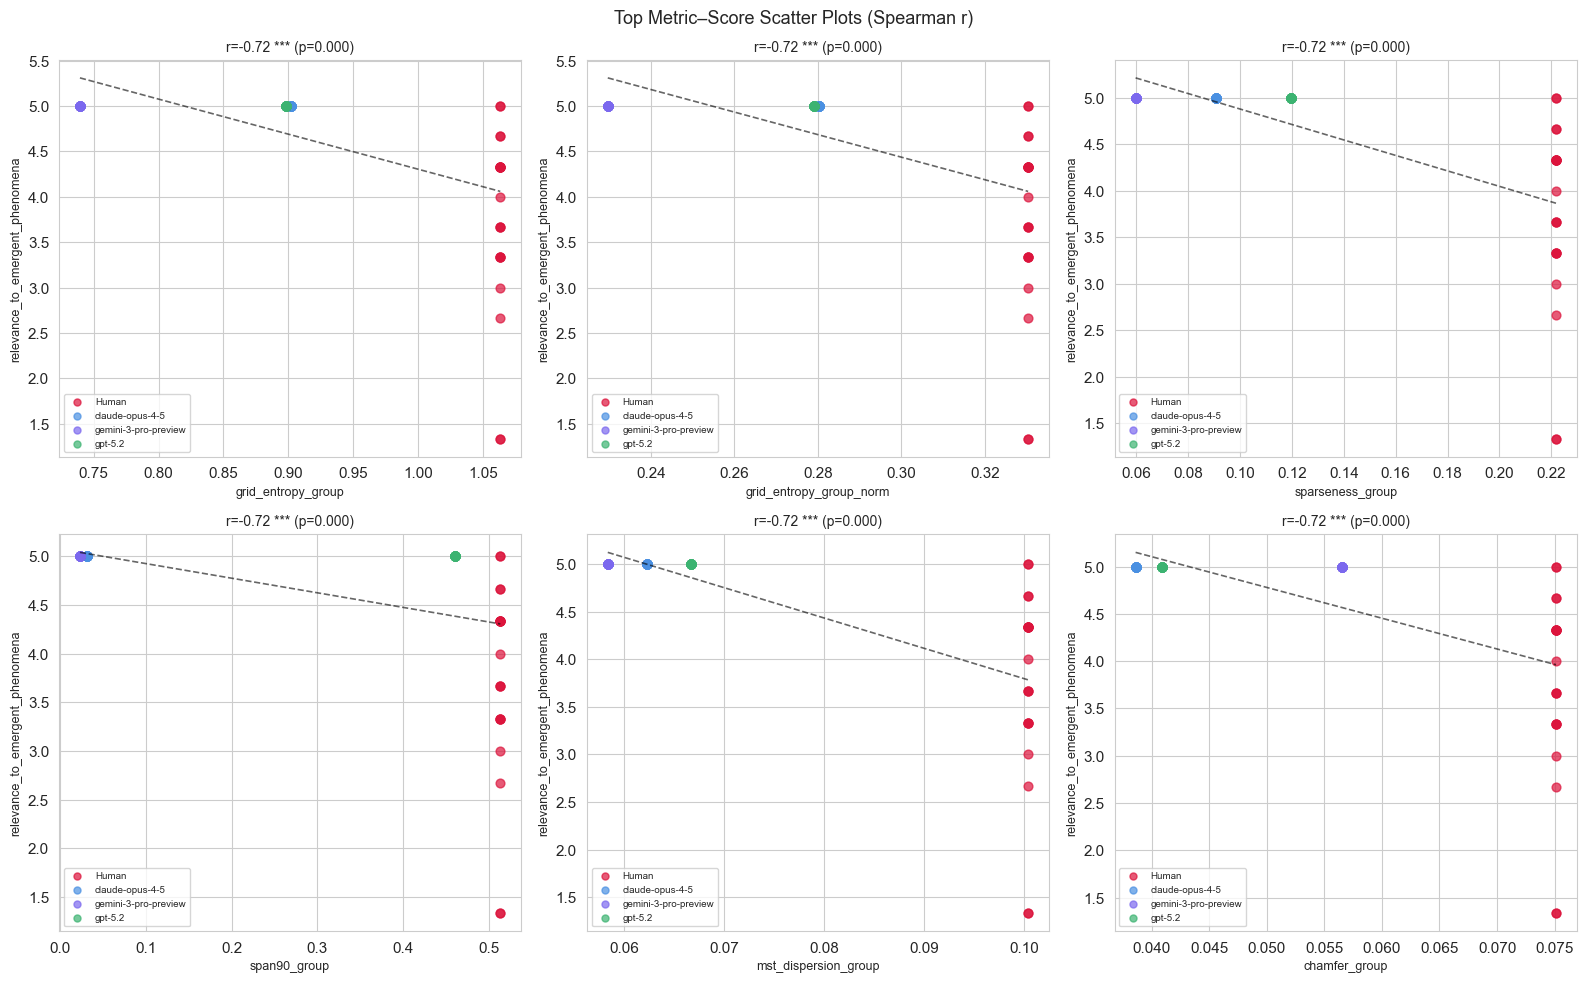

In [102]:
# Pick top 6 metric-score pairs (by |r|) across both correlation tables
all_corrs = (
    pd.concat([
        top_sem_ncems[['metric', 'score', 'spearman_r', 'p_value']],
        top_sem_nov[['metric', 'score', 'spearman_r', 'p_value']],
    ])
    .sort_values('spearman_r', key=abs, ascending=False)
    .drop_duplicates(subset=['metric', 'score'])
)

top_pairs = all_corrs.head(6)
display(top_pairs.round(4))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (_, row) in zip(axes.flat, top_pairs.iterrows()):
    m, s, r, p = row['metric'], row['score'], row['spearman_r'], row['p_value']
    subset = df[['group', m, s]].dropna()
    for grp, grp_df in subset.groupby('group'):
        ax.scatter(grp_df[m], grp_df[s], label=grp,
                   color=colors.get(grp, 'gray'), alpha=0.7, s=40)
    # OLS regression line
    x_vals  = subset[m].values
    y_vals  = subset[s].values
    z       = np.polyfit(x_vals, y_vals, 1)
    x_sorted = np.sort(x_vals)
    ax.plot(x_sorted, np.poly1d(z)(x_sorted), 'k--', linewidth=1.2, alpha=0.6)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    ax.set_xlabel(m, fontsize=9)
    ax.set_ylabel(s, fontsize=9)
    ax.set_title(f'r={r:.2f} {sig} (p={p:.3f})', fontsize=10)
    ax.legend(fontsize=7, markerscale=0.8)

plt.suptitle('Top Metric–Score Scatter Plots (Spearman r)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_scatter_metric_score.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Group-Level Analysis: Human vs AI

Do Human and AI proposals differ in their review scores, and in their metric-score relationships?

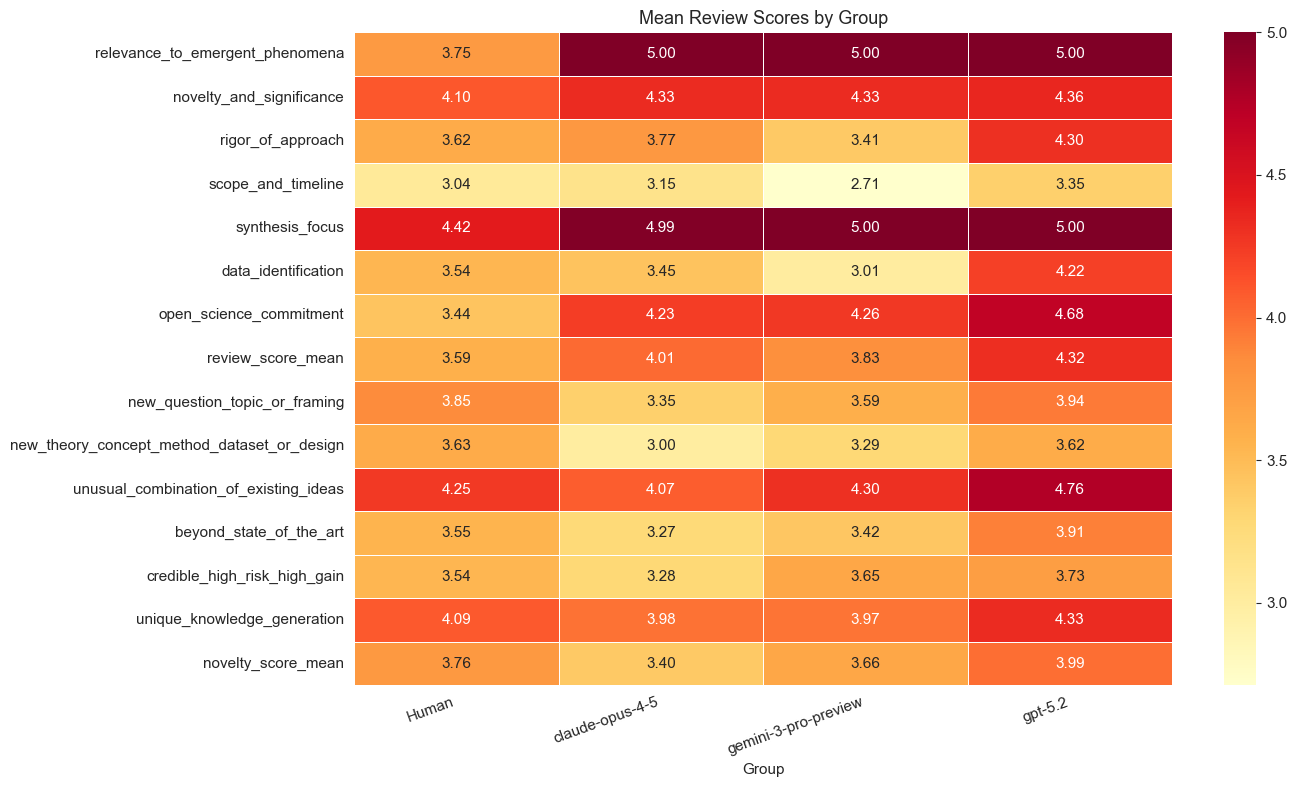

group                                        Human  claude-opus-4-5  \
relevance_to_emergent_phenomena              3.754            5.000   
novelty_and_significance                     4.101            4.333   
rigor_of_approach                            3.623            3.768   
scope_and_timeline                           3.043            3.145   
synthesis_focus                              4.420            4.986   
data_identification                          3.536            3.449   
open_science_commitment                      3.435            4.232   
review_score_mean                            3.586            4.009   
new_question_topic_or_framing                3.855            3.348   
new_theory_concept_method_dataset_or_design  3.630            3.000   
unusual_combination_of_existing_ideas        4.254            4.072   
beyond_state_of_the_art                      3.551            3.268   
credible_high_risk_high_gain                 3.536            3.283   
unique

In [103]:
# Mean scores by group
score_cols_all = NCEMS_SCORES + NOVELTY_SCORES
group_means    = df.groupby('group')[score_cols_all].mean().round(3).T

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(group_means, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Mean Review Scores by Group', fontsize=13)
ax.set_xlabel('Group')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'group_score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(group_means)

AI proposals: 69 | Human proposals: 23


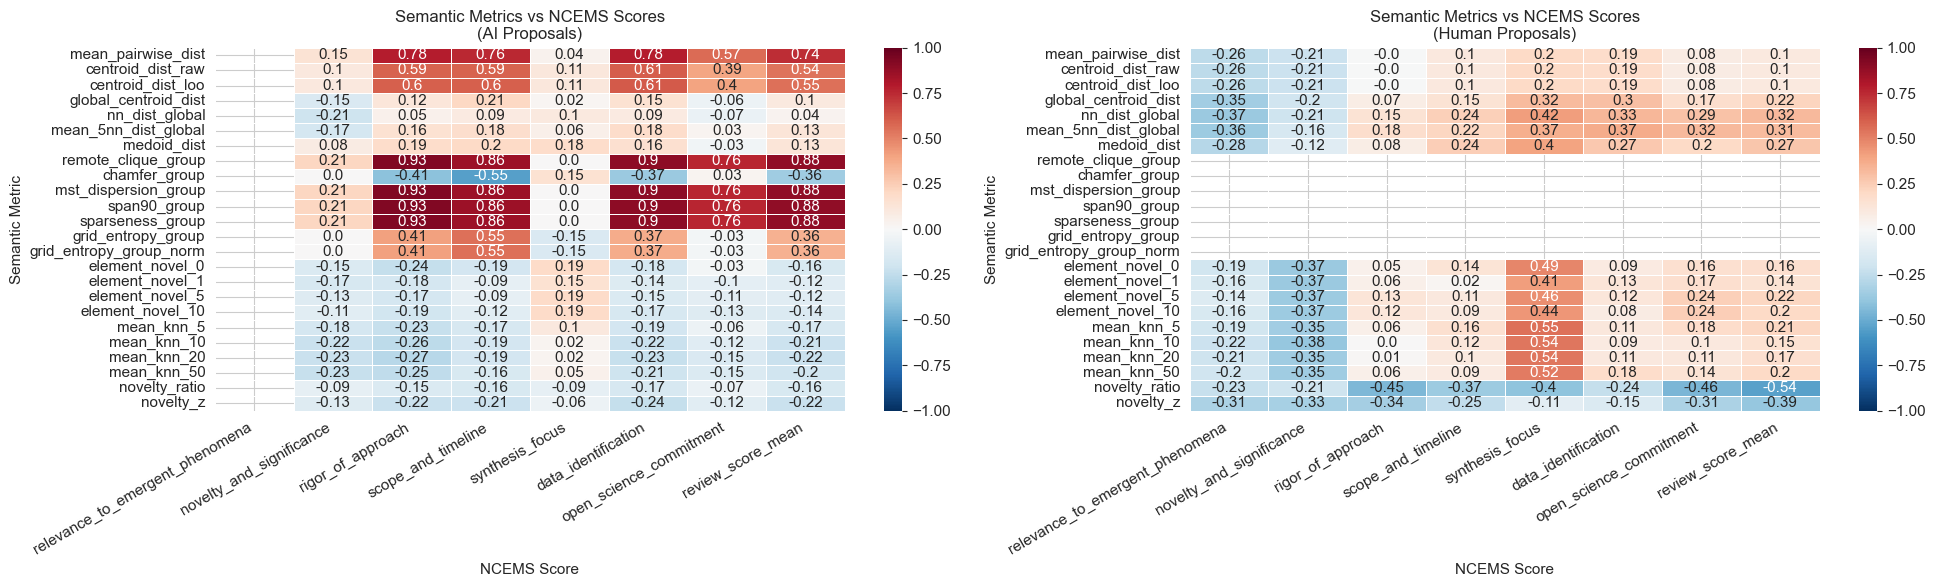

In [104]:
# Human vs AI: separate correlation heatmaps
df_ai    = df[df['is_ai'] == True].copy()
df_human = df[df['is_ai'] == False].copy()

print(f"AI proposals: {len(df_ai)} | Human proposals: {len(df_human)}")

corr_ai_ncems    = compute_corr_matrix(df_ai,    SEMANTIC_METRICS, NCEMS_SCORES)
corr_human_ncems = compute_corr_matrix(df_human, SEMANTIC_METRICS, NCEMS_SCORES)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, corr, label in zip(axes,
                             [corr_ai_ncems, corr_human_ncems],
                             ['AI Proposals', 'Human Proposals']):
    sns.heatmap(corr, annot=corr.round(2), fmt='',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title(f'Semantic Metrics vs NCEMS Scores\n({label})', fontsize=12)
    ax.set_xlabel('NCEMS Score')
    ax.set_ylabel('Semantic Metric')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_ai_vs_human_ncems.png', dpi=150, bbox_inches='tight')
plt.show()

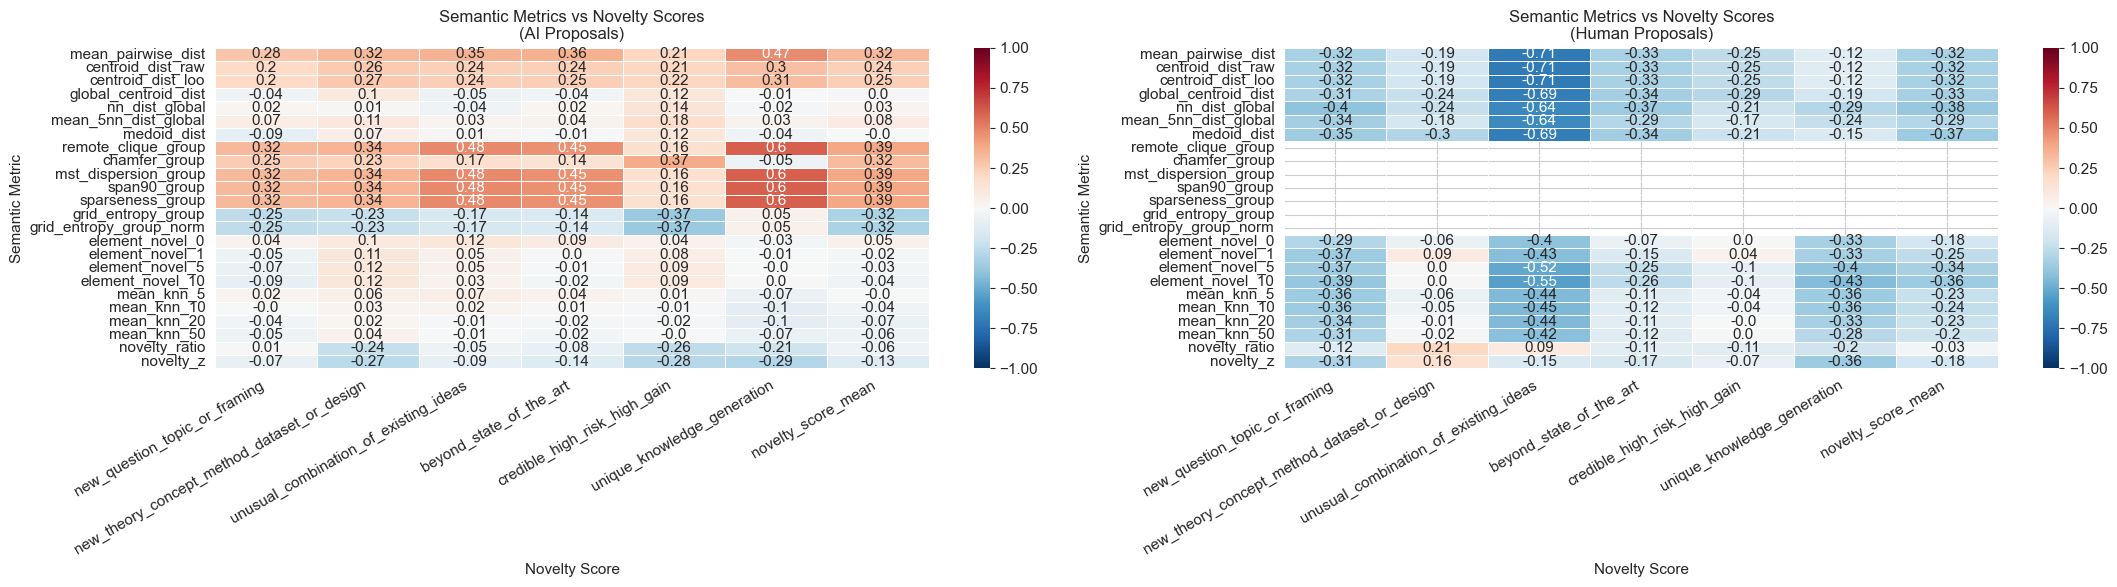

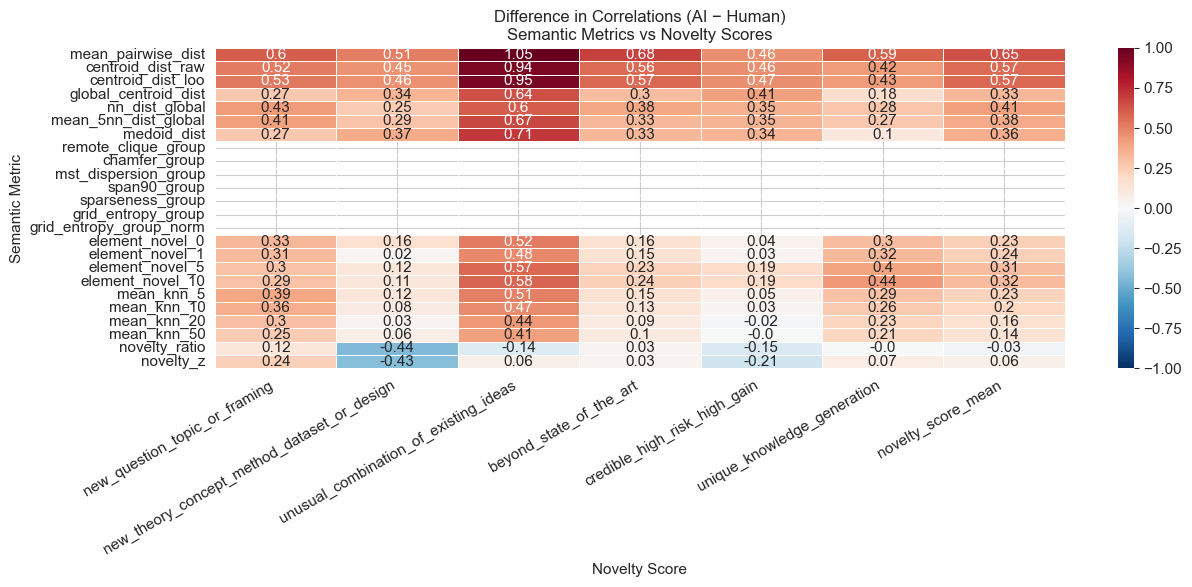

In [105]:
# Human vs AI: semantic metrics vs Novelty scores
corr_ai_nov    = compute_corr_matrix(df_ai,    SEMANTIC_METRICS, NOVELTY_SCORES)
corr_human_nov = compute_corr_matrix(df_human, SEMANTIC_METRICS, NOVELTY_SCORES)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
for ax, corr, label in zip(axes,
                             [corr_ai_nov, corr_human_nov],
                             ['AI Proposals', 'Human Proposals']):
    sns.heatmap(corr, annot=corr.round(2), fmt='',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title(f'Semantic Metrics vs Novelty Scores\n({label})', fontsize=12)
    ax.set_xlabel('Novelty Score')
    ax.set_ylabel('Semantic Metric')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_ai_vs_human_novelty.png', dpi=150, bbox_inches='tight')
plt.show()

# Difference heatmap: AI minus Human
diff_nov = corr_ai_nov - corr_human_nov
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(diff_nov, annot=diff_nov.round(2), fmt='',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Difference in Correlations (AI − Human)\nSemantic Metrics vs Novelty Scores', fontsize=12)
ax.set_xlabel('Novelty Score')
ax.set_ylabel('Semantic Metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_diff_ai_human_novelty.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Statistics Table

Saved correlation and p-value tables.


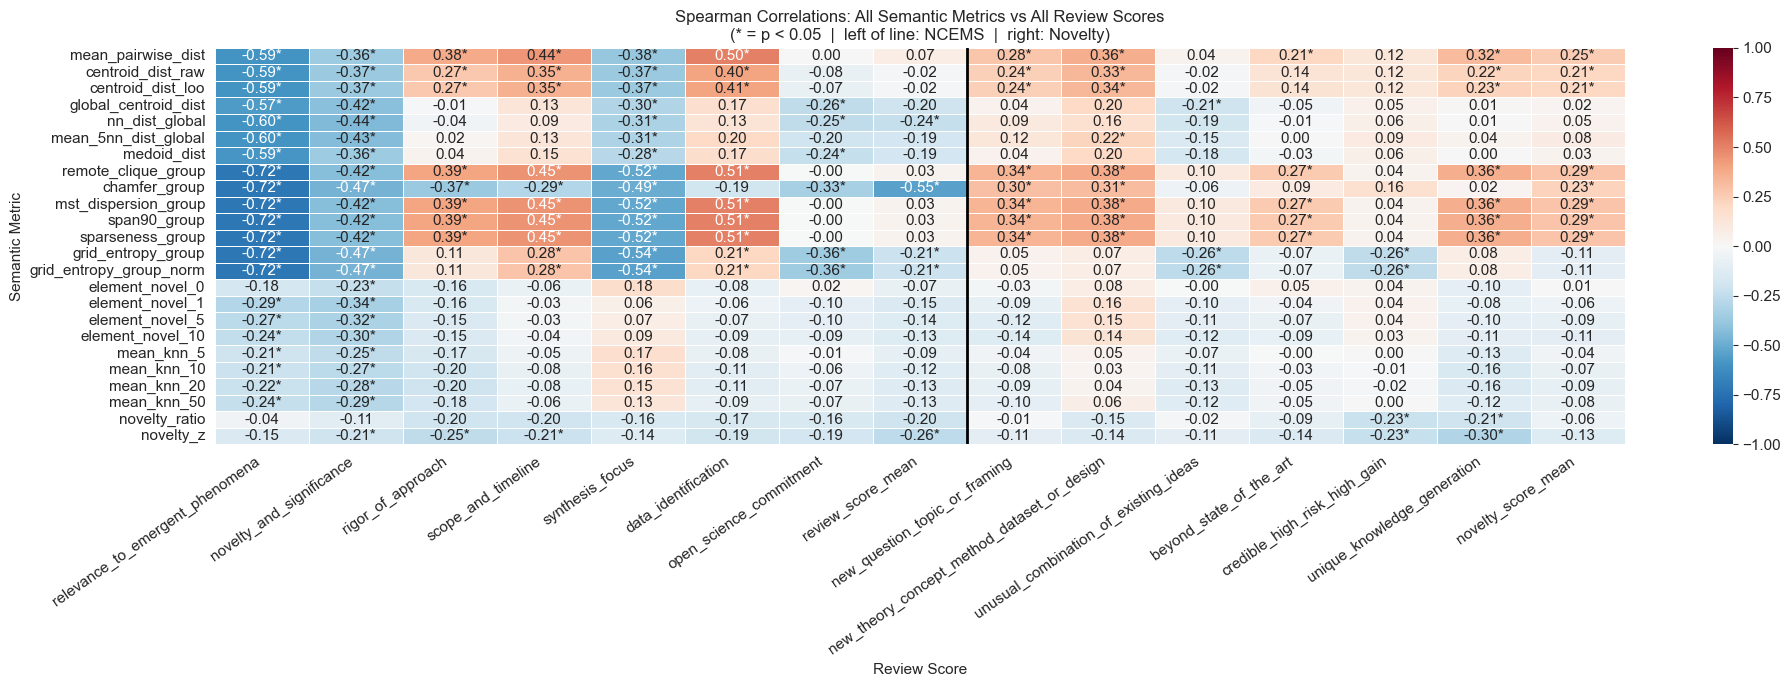

In [106]:
# Full correlation matrix: all semantic metrics vs all review scores
all_metric_score_corr = compute_corr_matrix(df, SEMANTIC_METRICS, NCEMS_SCORES + NOVELTY_SCORES)
all_metric_score_pval = compute_pval_matrix(df, SEMANTIC_METRICS, NCEMS_SCORES + NOVELTY_SCORES)

# Save to CSV
all_metric_score_corr.round(4).to_csv(TABLES_DIR / 'spearman_corr_semantic_all_scores.csv')
all_metric_score_pval.round(6).to_csv(TABLES_DIR / 'spearman_pval_semantic_all_scores.csv')
print("Saved correlation and p-value tables.")

fig, ax = plt.subplots(figsize=(20, 7))
annot_full = all_metric_score_corr.round(2).astype(str)
for m in SEMANTIC_METRICS:
    for s in NCEMS_SCORES + NOVELTY_SCORES:
        r = all_metric_score_corr.loc[m, s]
        p = all_metric_score_pval.loc[m, s]
        annot_full.loc[m, s] = f"{r:.2f}{'*' if p < 0.05 else ''}"

sns.heatmap(
    all_metric_score_corr, annot=annot_full, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.axvline(x=len(NCEMS_SCORES), color='black', linewidth=2)
ax.set_title(
    'Spearman Correlations: All Semantic Metrics vs All Review Scores\n'
    '(* = p < 0.05  |  left of line: NCEMS  |  right: Novelty)', fontsize=12
)
ax.set_xlabel('Review Score')
ax.set_ylabel('Semantic Metric')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'corr_all_semantic_all_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [107]:
# Export the final DataFrame for downstream use
df.to_csv(TABLES_DIR / 'metric_score_df.csv', index=False)
print(f"Exported flat DataFrame with {df.shape[0]} rows and {df.shape[1]} columns to:")
print(f"  {TABLES_DIR / 'metric_score_df.csv'}")

Exported flat DataFrame with 92 rows and 66 columns to:
  /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/metric-score/metric_score_df.csv
